In [1]:
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import sys
import os

module_path = os.path.abspath(os.path.join(os.getcwd(), '..'))
if module_path not in sys.path:
    sys.path.append(module_path)

import functions
import plot_config as pc

pc.apply_custom_mpl_settings()

<h1><span style="color:orange">Numerical Simulation Laboratory (NSL)</span></h1>

<h2><span style="color:green">Numerical Exercise 8</span></h2>

This notebook aims to apply the **Simulated Annealing (SA) optimization method** to a quantum mechanical problem. The goal is to obtain the **best approximation of the ground state (GS)** for a single particle in a one-dimensional space, subject to the external potential:

$$\mathcal{V}(x) = x^4 -\frac{5x^2}{2}.$$

The trial wavefunction proposed to parametrize the approximate ground state is defined as follows:

$$\Psi_{T}^{\mu, \sigma} \propto e^{-\frac{(x-\mu)^2}{2\sigma^2}} + e^{-\frac{(x+\mu)^2}{2\sigma^2}}.$$

This optimization strategy relies on the **Variational Principle of Quantum Mechanics**. This principle states that the expectation value of the Hamiltonian $\hat{H}$, calculated using an arbitrary trial wavefunction $\Psi_T$ (provided it satisfies the necessary physical conditions, such as square-integrability), has as a lower bound the true ground state energy $E_0$:

$$\langle {\hat H} \rangle_T = \frac{\langle \Psi_T | {\hat H} | \Psi_T \rangle}{\langle \Psi_T | \Psi_T \rangle} \ge E_0 = \frac{\langle \Psi_0 | {\hat H} | \Psi_0 \rangle}{\langle \Psi_0 | \Psi_0 \rangle}.$$

Consequently, by minimizing this expectation value with respect to the variational parameters ($\mu$ and $\sigma$), we can identify the optimal parameter set that best approximates the ground state configuration.

Since the integral required to compute the Hamiltonian's expectation value is not analytically solvable for this specific model, we employ a numerical approach known as **Variational Monte Carlo (VMC)**.

The notebook is structured into three main sections:

1. [Implementation and simulation of the VMC](#vmc).

2. [SA implementation and GS parameters optimization](#sa)

3. [Estimation of the expectation value of the Hamiltonian](#h-mean-value) for the approximate GS, using the optimal parameters identified via SA.

<h3><span style="color:darkviolet">Variational Monte Carlo VMC</span></h3>

Frequently, the expectation value of the Hamiltonian for a specific wavefunction cannot be computed analytically, necessitating a numerical approach. These algorithms, which apply Monte Carlo methods to the study of quantum many-body systems, are collectively known as Quantum Monte Carlo methods.

The fundamental idea is to recast the analytic expression for the expectation value, typically written in Dirac notation, to define a probability density, specifically the squared modulus of the wavefunction, over which the average is computed. Since this probability density is generally complex and cannot be sampled efficiently using direct Monte Carlo techniques, the Metropolis-Hastings algorithm is employed. Consequently, we obtain:

$$\langle \hat{H} \rangle_T = 
\frac{\langle \Psi_T | \hat{H} | \Psi_T \rangle}{\langle \Psi_T | \Psi_T \rangle} = 
\frac{\int dx~\Psi^{\star}_T(x)~\hat{H}~\Psi_T(x)}{\int dx~\lvert \Psi_T(x) \rvert ^2} = 
\frac{\int dx~\Psi^{\star}_T(x)~\Psi_T(x)~\frac{\hat{H}~\Psi_T(x)}{\Psi_T(x)}}{\int dx~\lvert \Psi_T(x) \rvert ^2} =
\int dx~\frac{\lvert \Psi_T(x) \rvert^2}{\int dx~\lvert \Psi_T(x) \rvert ^2}~\frac{\hat{H}~\Psi_T(x)}{\Psi_T(x)} =
\int dx~p(x)~E_{loc}(x),$$

where $p(x)$ is the properly normalized probability density associated with the quantum state, and $E_{loc}(x)$ is the local energy. The latter can be computed analytically by applying the Hamiltonian operator $\hat{H} = -\frac{\hbar^2}{2m}\nabla^2 + \mathcal{V}(x)$ to the trial wavefunction $\Psi_T(x)$ and dividing the result by the wavefunction itself.

In our specific case, since the external potential operator is diagonal in the coordinate representation, its action on the wavefunction corresponds to simple multiplication, extracting the scalar potential:

$$\frac{\hat{\mathcal{V}}(x) \Psi_T(x)}{\Psi_T(x)} = \mathcal{V}(x).$$

Regarding the kinetic part, by setting $\hbar = 1$ and $m=1$, we obtain:

$$-\frac{1}{2}\frac{\partial^2}{\partial x^2} \Psi_T(x) = 
\ldots = 
\frac{1}{\sigma^2} \left( \frac{1}{2} - \frac{\frac{(x-\mu)^2}{2\sigma^2}e^{-\frac{(x-\mu)^2}{2\sigma^2}} + \frac{(x+\mu)^2}{2\sigma^2}e^{-\frac{(x+\mu)^2}{2\sigma^2}}}{e^{-\frac{(x-\mu)^2}{2\sigma^2}} + e^{-\frac{(x+\mu)^2}{2\sigma^2}}}\right).$$

Thus, the estimation of the Hamiltonian's expectation value is given by:

$$\langle \hat{H} \rangle_T \simeq 
\frac{1}{N} \sum_{i = 1}^{N}E_{loc}(x_i) \quad \quad \text{ with } x_i \sim p(x) = \frac{\lvert \Psi_T(x) \rvert^2}{\int dx~\lvert \Psi_T(x) \rvert^2}.$$

<h4>Implementation</h4>

Given that the fundamental structure of a Variational Monte Carlo (VMC) simulation closely parallels that of a canonical ensemble simulation, specifically the calculation of an observable's expectation value with respect to a specific probability distribution describing the system, I opted to utilize the library already developed for Exercises 4, 6, and 7. I extended the existing codebase by introducing a new simulation type and incorporating the necessary components to address the specific requirements of the VMC algorithm.

The simulation models a system characterized by a single degree of freedom. Its position evolves via a one-dimensional random walk, utilizing uniform displacements centered on the current position with an amplitude of `_delta`. Since the transition probability is symmetric (uniform and centered on the previous position), the Metropolis acceptance probability is defined as the minimum between 1 and the ratio of the squared modulus of the trial wavefunction calculated for the proposed configuration versus the current one. Once a proposed move is accepted or rejected, the quantity of interest is evaluated and accumulated for the block averaging method, after which a new move is proposed.

To implement this system, I modified several methods within the `System` class:

- **Input Parameters**: I appended new properties to the input file, which are processed by the `initialize()` method:
    - `SIMULATION_TYPE = 4`: Designates that the system should perform a VMC simulation.
    - `NPARAM`: A line containing multiple values; the first specifies the number of parameters defining the trial wavefunction, while the subsequent values define the parameters themselves (in this specific case, we have two parameters, $\mu$ and $\sigma$).

- **Initialization Routine**: I updated the `initialize()` method to read these new inputs and set the corresponding private variables of the class:
    ```cpp
        void System :: initialize(){
            // ... //
            else if(_sim_type == 4) coutf << "VARIATIONAL MONTE CARLO (VMC) SIMULATION" << endl;
            // ... //
            else if( property == "NPARAM"){
                input >> _nparam;
                coutf << "NPARAM= " << _nparam << "       ";
                _parameters.set_size(_nparam);
                _parameters.zeros();
                for(int i{}; i < _nparam; i++){
                input >> _parameters(i);
                coutf << "PARAM(" << i <<")=" << _parameters(i) << "       ";
                }
                coutf << endl;
                _parameters_current.set_size(_nparam);
                _parameters_current.zeros();
            }
            // ... // 
        }
    ```

- **Configuration File**: I modified the positional configuration file `config.xyz`, read by the `read_configuration()` method, to represent a single particle in a one-dimensional space:
    ```text
        1
        #Comment!
        VMC  -0.900000    0.000000    0.000000
    ```

- Measurement Flags: I introduced a flag, `_measure_loc_energy`, which is set to true when the `LOCAL_ENERGY` property is read from the `properties.dat` file, along with its corresponding index `_index_loc_energy` within the `_measurement` vector. This logic is handled within the `initialize_properties()` method, following the workflow of the existing implementation.

- **Metropolis-Hastings Algorithm**: I implemented the Metropolis-Hastings step routine, designing it to be as generic as possible to allow for future applications to multi-particle systems in three-dimensional space (to be totally generic we should define both velocity and force $N_{dim} X N_{part}$ or $N_{part} X N_{dim}$ matrix):
    ```cpp
        void System :: step(){ 
            // ... //
            else{
                for(int i=0; i<_npart; i++){
                    this->move(i);
                }
            }
            // ... //
        }
    ```
    ```cpp
        void System :: move(int i){
            // ... //
            else if(_sim_type == 4){
                vec shift(_ndim);
                shift(0) = _rnd.Rannyu(-1.0,1.0) * _delta;
                shift(1) = 0.0;
                shift(2) = 0.0;
                _particle(i).translate(shift);
                if(this->metro(i)){
                    _particle(i).acceptmove();
                    _naccepted++;
                } else _particle(i).moveback();
            }
            return;
        }
    ```
    ```cpp
        bool System :: metro(int i){
            bool decision = false;
            double delta_E, acceptance;
            // ... //
            else if (_sim_type == 4){
                acceptance = this->Psi2(i,true)/this->Psi2(i, false);
                if(_rnd.Rannyu(0.0,1.0) < acceptance){
                    decision = true;
                }
            }
            return decision;
        }
    ```

- **Wavefunction Evaluation**: I added a dedicated function to calculate the squared modulus of the trial wavefunction:
    ```cpp
        double System :: Psi2(int i, bool xnew){
            double a{_particle(i).getposition(0, xnew) - _parameters(0)};
            double b{_particle(i).getposition(0, xnew) + _parameters(0)};
            double c{0.5/(_parameters(1) * _parameters(1))};
            double d{(-1.0)*a*a*c};
            double f{(-1.0)*b*b*c};
            double e_1{exp(d)};
            double e_2{exp(f)};
            double psi{e_1 + e_2};
            return psi*psi;
        }
    ```

- **Local Energy Measurement**: I incorporated the local energy calculation routine into the `measure()` method, implementing the derived analytical formulas:
    ```cpp
        void System :: measure(){
            // ... //
            if (_measure_loc_energy){
                double x = _particle(0).getposition(0, true);
                double x1 = x - _parameters(0);
                double x2 = x + _parameters(0);
                double d = 1.0/(_parameters(1)*_parameters(1));
                double y1 = 0.5 * d * x1 * x1;
                double y2 = 0.5 * d * x2 * x2;
                double e1 = exp((-1.0)*y1);
                double e2 = exp((-1-0)*y2);
                double h_loc = d * (0.5 - (y1*e1 + y2*e2)/(e1+e2));
                double v = x*x*x*x - 2.5*x*x;
                _measurement(_index_loc_energy) = h_loc + v;
            } // ... //
        }

- **Data Averaging**: I updated the `averages()` method to handle the block averaging, as well as the progressive mean and uncertainty for the local energy:
    ```cpp
        void System :: averages(int blk){
            // ... //
            if(_measure_loc_energy){
                average  = _average(_index_loc_energy);
                sum_average = _global_av(_index_loc_energy);
                sum_ave2 = _global_av2(_index_loc_energy);
                if(_print_vmc){
                    coutf.open("../OUTPUT/hamiltonian.dat",ios::app);
                    coutf << setw(12) << blk
                          << setw(20) << average
                          << setw(20) << sum_average/double(blk)
                          << setw(20) << this->error(sum_average, sum_ave2, blk) << endl;
                    coutf.close();
                }
            }
        }
    ```

**NB**: To be fully generalizable to $n$-particle systems in $N$ dimensions, the code should utilize $(N_{dim} \times N_{part})$ or $(N_{part} \times N_{dim})$ matrices. Furthermore, it should incorporate a C++ automatic differentiation library (e.g., AUTODIFF) to enable the computation of the Laplacian operator $\nabla^2$ independently of the specific trial ground state wavefunction used.

<h4>Simulation</h4>

To evaluate the performance of the implemented code, I performed three distinct simulations initialized with different walker positions. The primary objective was to analyze the equilibration time of the Metropolis algorithm—specifically, how rapidly it begins to correctly sample the target distribution $p(x)$ as a function of the starting coordinate. Consequently, I conducted three simulations of 5000 steps each, recording the Metropolis acceptance rate, the instantaneous local energy, and the walker's position at every step.

The simulations were performed using the following input parameters:

<div align="center">

| Parameters | SIMULATION 1 | SIMULATION 2 | SIMULATION 3 |
| :--- | :--- | :--- | :--- |
| SIMULATION_TYPE | 4 | 4 | 4 |
| RESTART | 0 | 0 | 0 |
| NPART | 1 | 1 | 1 |
| X0 | 10.0 | -0.30 | -0.80 |
| R_CUT | 2.5 | 2.5 | 2.5 |
| DELTA | 2.65 | 2.65 | 2.65 |
| NBLOCKS | 5000 | 5000 | 5000 |
| NSTEPS | 1 | 1 | 1 |
| NPARAM | 2 0.8 0.6 | 2 0.8 0.6 | 2 0.8 0.6 |

</div>

In [2]:
pos1 = np.loadtxt("equilibration/scenario1/OUTPUT/walker.dat", usecols=(0), unpack=True)
pos2 = np.loadtxt("equilibration/scenario2/OUTPUT/walker.dat", usecols=(0), unpack=True)
pos3 = np.loadtxt("equilibration/scenario3/OUTPUT/walker.dat", usecols=(0), unpack=True)

step, acceptance1 = np.loadtxt("equilibration/scenario1/OUTPUT/acceptance.dat", usecols=(0,1), unpack=True)
acceptance2 = np.loadtxt("equilibration/scenario2/OUTPUT/acceptance.dat", usecols=(1))
acceptance3 = np.loadtxt("equilibration/scenario3/OUTPUT/acceptance.dat", usecols=(1))
h1, H1 = np.loadtxt("equilibration/scenario1/OUTPUT/hamiltonian.dat", usecols=(1,2), unpack=True)
h2, H2 = np.loadtxt("equilibration/scenario2/OUTPUT/hamiltonian.dat", usecols=(1,2), unpack=True)
h3, H3 = np.loadtxt("equilibration/scenario3/OUTPUT/hamiltonian.dat", usecols=(1,2), unpack=True)

xmin = min(step) - 100
xmax = max(step) + 100
acf_step = len(step)

mu, sigma = functions.leggi_nparam_da_input("equilibration/scenario1/INPUT/input.dat")

walker_start1 = np.loadtxt("equilibration/scenario1/INPUT/CONFIG/config.xyz", skiprows=2, usecols=(1))
walker_start2 = np.loadtxt("equilibration/scenario2/INPUT/CONFIG/config.xyz", skiprows=2, usecols=(1))
walker_start3 = np.loadtxt("equilibration/scenario3/INPUT/CONFIG/config.xyz", skiprows=2, usecols=(1))

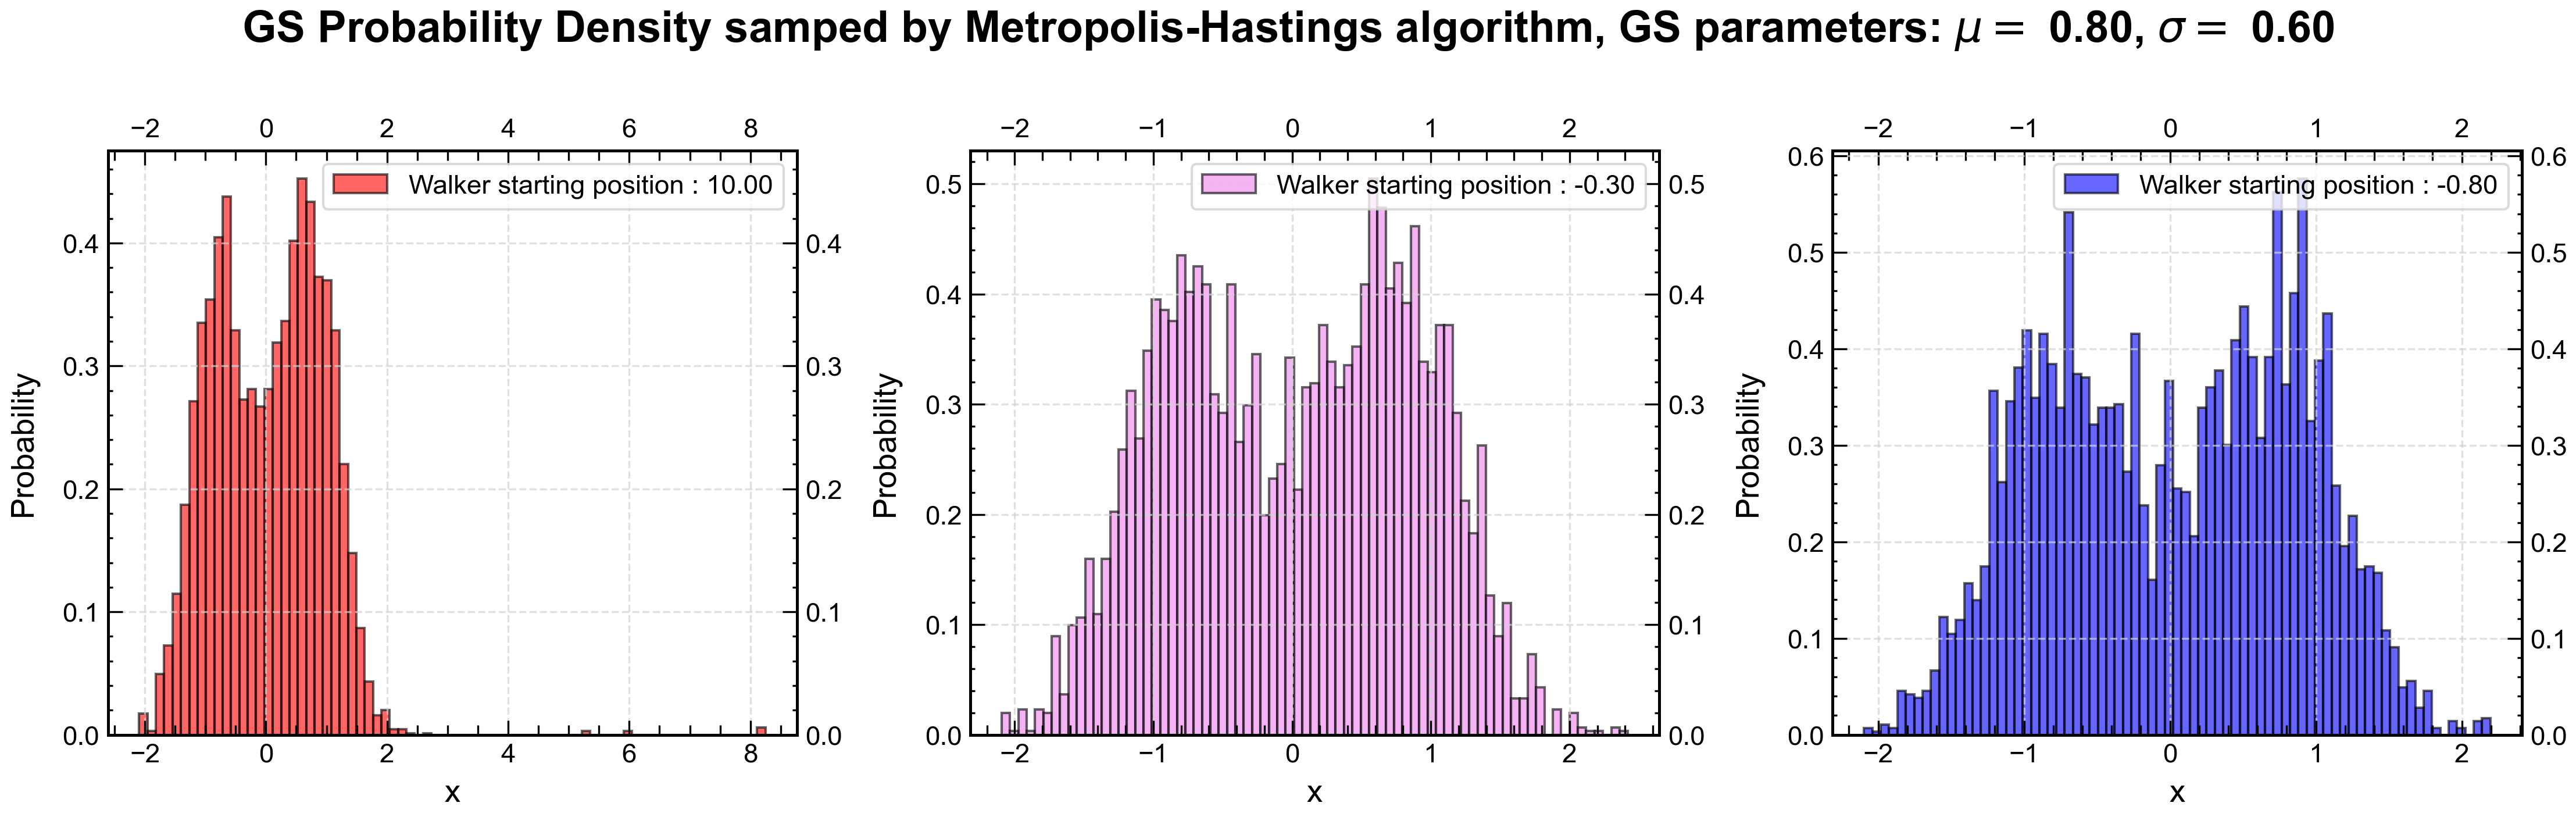

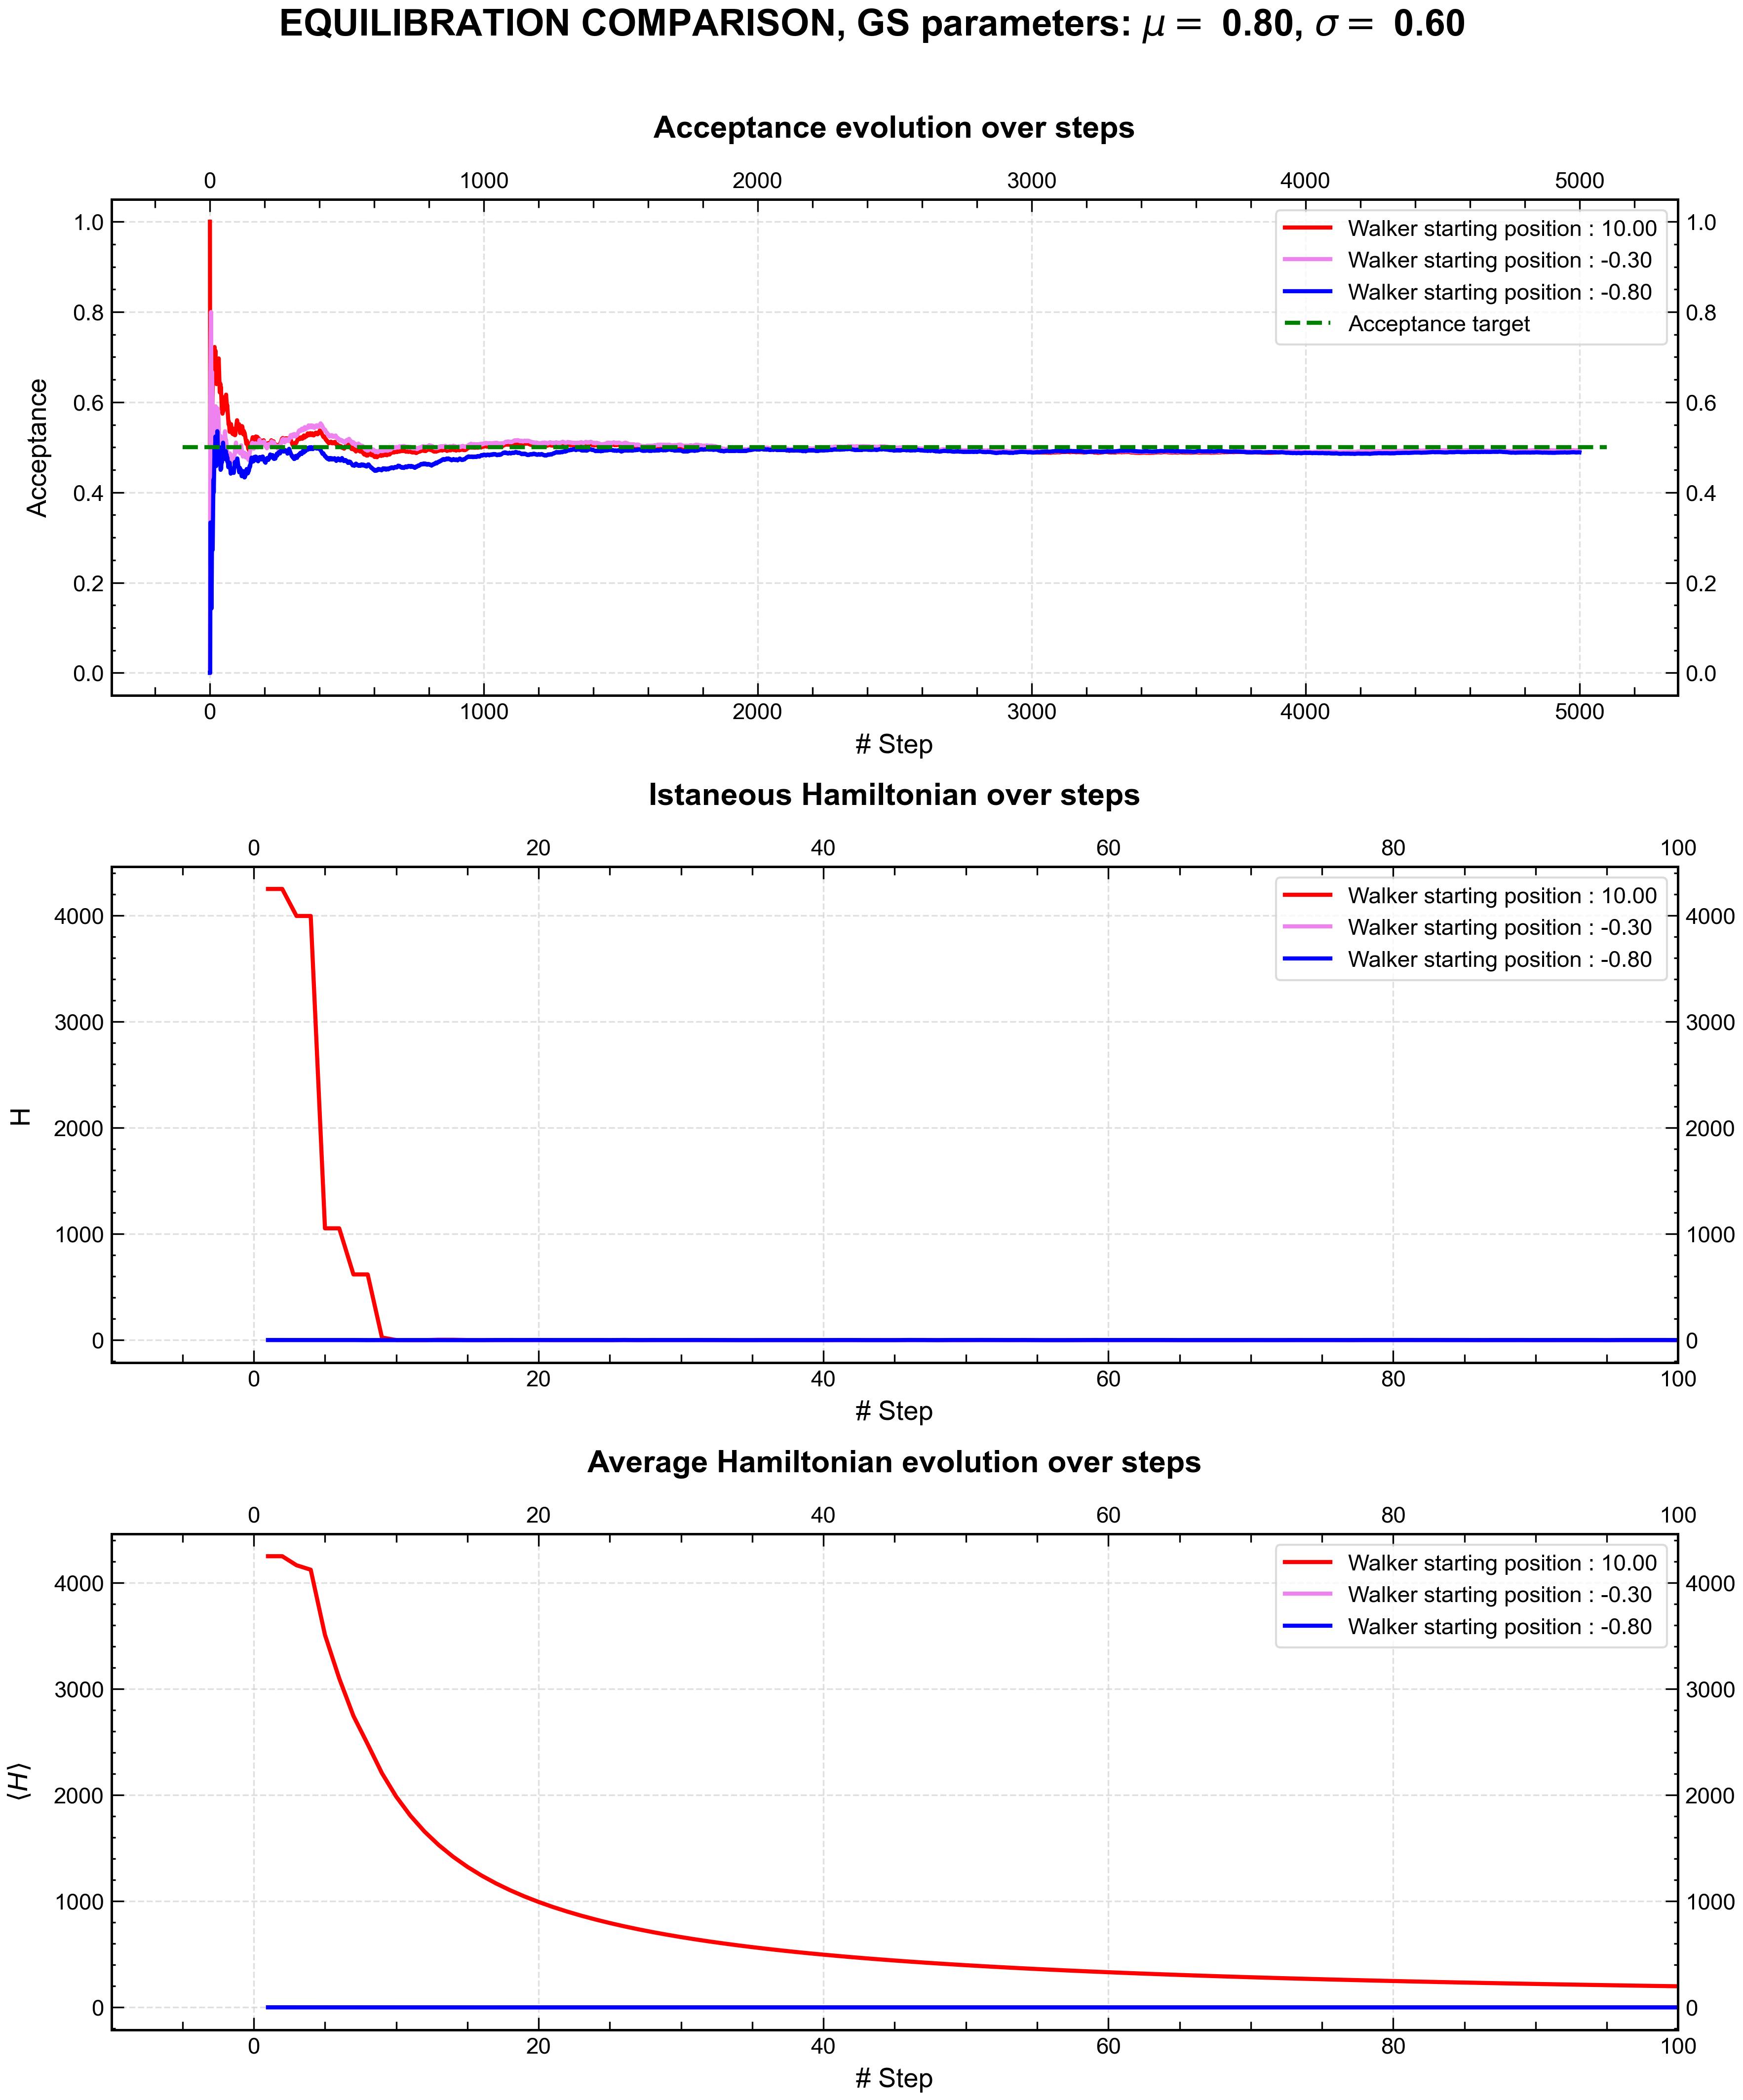

In [3]:
fig, axs = plt.subplots(1,3,figsize=(15,5))

plt.suptitle(rf"GS Probability Density samped by Metropolis-Hastings algorithm, GS parameters: $\mu = $ {mu:.2f}, $\sigma =$ {sigma:.2f}", fontsize=18, fontweight='bold')

axs[0].hist(pos1, bins=75, color='red', alpha=0.6, density=True, edgecolor='black', label=f'Walker starting position : {walker_start1:.2f}')
axs[0].set_xlabel('x', labelpad=5)
axs[0].set_ylabel('Probability', labelpad=10)
axs[0].legend()
axs[1].hist(pos2, bins=75, color='violet', alpha=0.6, density=True, edgecolor='black', label=f'Walker starting position : {walker_start2:.2f}')
axs[1].set_xlabel('x', labelpad=5)
axs[1].set_ylabel('Probability', labelpad=10)
axs[1].legend()
axs[2].hist(pos3, bins=75, color='blue', alpha=0.6, density=True, edgecolor='black', label=f'Walker starting position : {walker_start3:.2f}')
axs[2].set_xlabel('x', labelpad=5)
axs[2].set_ylabel('Probability', labelpad=10)
axs[2].legend()

fig.tight_layout(rect=[0, 0.03, 1, 0.97])

fig, axs = plt.subplots(3,1,figsize=(12,15))

plt.suptitle(rf"EQUILIBRATION COMPARISON, GS parameters: $\mu = $ {mu:.2f}, $\sigma =$ {sigma:.2f}", fontsize=18, fontweight='bold')

axs[0].set_title("Acceptance evolution over steps", pad=30)
axs[0].plot(step, acceptance1, color='red', label=f'Walker starting position : {walker_start1:.2f}')
axs[0].plot(step, acceptance2, color='violet', label=f'Walker starting position : {walker_start2:.2f}')
axs[0].plot(step, acceptance3, color='blue', label=f'Walker starting position : {walker_start3:.2f}')
axs[0].set_xlabel('# Step', labelpad=5)
axs[0].set_ylabel('Acceptance', labelpad=10)
axs[0].hlines(0.5, xmin, xmax, color='green', linestyle='--', label='Acceptance target')
axs[0].legend()

axs[1].set_title("Istaneous Hamiltonian over steps", pad=30)
axs[1].plot(step, h1, color='red', label=f'Walker starting position : {walker_start1:.2f}')
axs[1].plot(step, h2, color='violet', label=f'Walker starting position : {walker_start2:.2f}')
axs[1].plot(step, h3, color='blue', label=f'Walker starting position : {walker_start3:.2f}')
axs[1].set_xlabel('# Step', labelpad=5)
axs[1].set_ylabel('H', labelpad=10)
axs[1].set_xlim(-10, 100)
axs[1].legend()

axs[2].set_title("Average Hamiltonian evolution over steps", pad=30)
axs[2].plot(step, H1, color='red', label=f'Walker starting position : {walker_start1:.2f}')
axs[2].plot(step, H2, color='violet', label=f'Walker starting position : {walker_start2:.2f}')
axs[2].plot(step, H3, color='blue', label=f'Walker starting position : {walker_start3:.2f}')
axs[2].set_xlabel('# Step', labelpad=5)
axs[2].set_ylabel(r'$\langle H \rangle$', labelpad=10)
axs[2].set_xlim(-10, 100)
axs[2].legend()

fig.tight_layout(rect=[0, 0.03, 1, 0.97])
plt.show()

<h4>Conclusions</h4>

We observe that by setting the Metropolis step width to $\Delta = 2.65$, regardless of the initial walker position, the MCMC sampling of the trial wavefunction squared modulus $|\Psi_T(x)|^2$ reaches a stable acceptance rate of $50\%$ after approximately 2000 steps. This rate falls within the optimal range typically required by the Metropolis-Hastings algorithm

A closer inspection of the instantaneous local energy trajectory reveals that, even when initializing the walker far from the target probability density, the system begins sampling energy values compatible with the target distribution within 10–20 Monte Carlo steps. These values align with those observed in simulations initialized within the high-probability region. This behavior is further evidenced by the three histograms displaying the probability density sampled by the Metropolis algorithm. Even when starting from a position distant from regions of non-negligible density, the algorithm quickly converges to the correct sampling distribution (indicated by the low normalized count of outliers corresponding to the initial transient phase).

However, **a crucial consideration addresses the bias introduced by initialization**. When starting from a highly anomalous position distant from the correct sampling regions, the instantaneous local energy can differ from the expected value by a factor of $10^4$. Consequently, the cumulative mean of the Hamiltonian is heavily biased by these initial outliers sampled in regions of vanishingly small probability. For this reason, a slower convergence of the mean value toward the true expectation value is observed. Therefore, **it is strongly recommended to initialize the algorithm** such that the walker starts at a position consistent with the target probability density (or to discard the initial equilibration steps).

In [4]:
step, h = np.loadtxt("ac_simulation/OUTPUT/hamiltonian.dat", usecols=(0,1), unpack=True)
# Minimum block size
L_min = 1
# Maximum block size
L_max = 5000
# Array of tested block sizes
L_values = np.arange(L_min, L_max + 1)
# Number of block sizes attempted
num_L = len(L_values)
# Arrays for calculated errors corresponding to successive block sizes
err = np.zeros(num_L)

# Loop over the tested block sizes and fill the respective error arrays
for i in range(num_L):
    L = L_values[i]
    err[i] = functions.data_blocking(h, L)

In [5]:
acf_step = 10000
step = step[:acf_step]
h = h[:acf_step]
var = np.var(h)
acf = functions.unbiased_acf(h, var)

NVE Correlation time from unbiased sample ACF : τ ≈ 3.19 steps


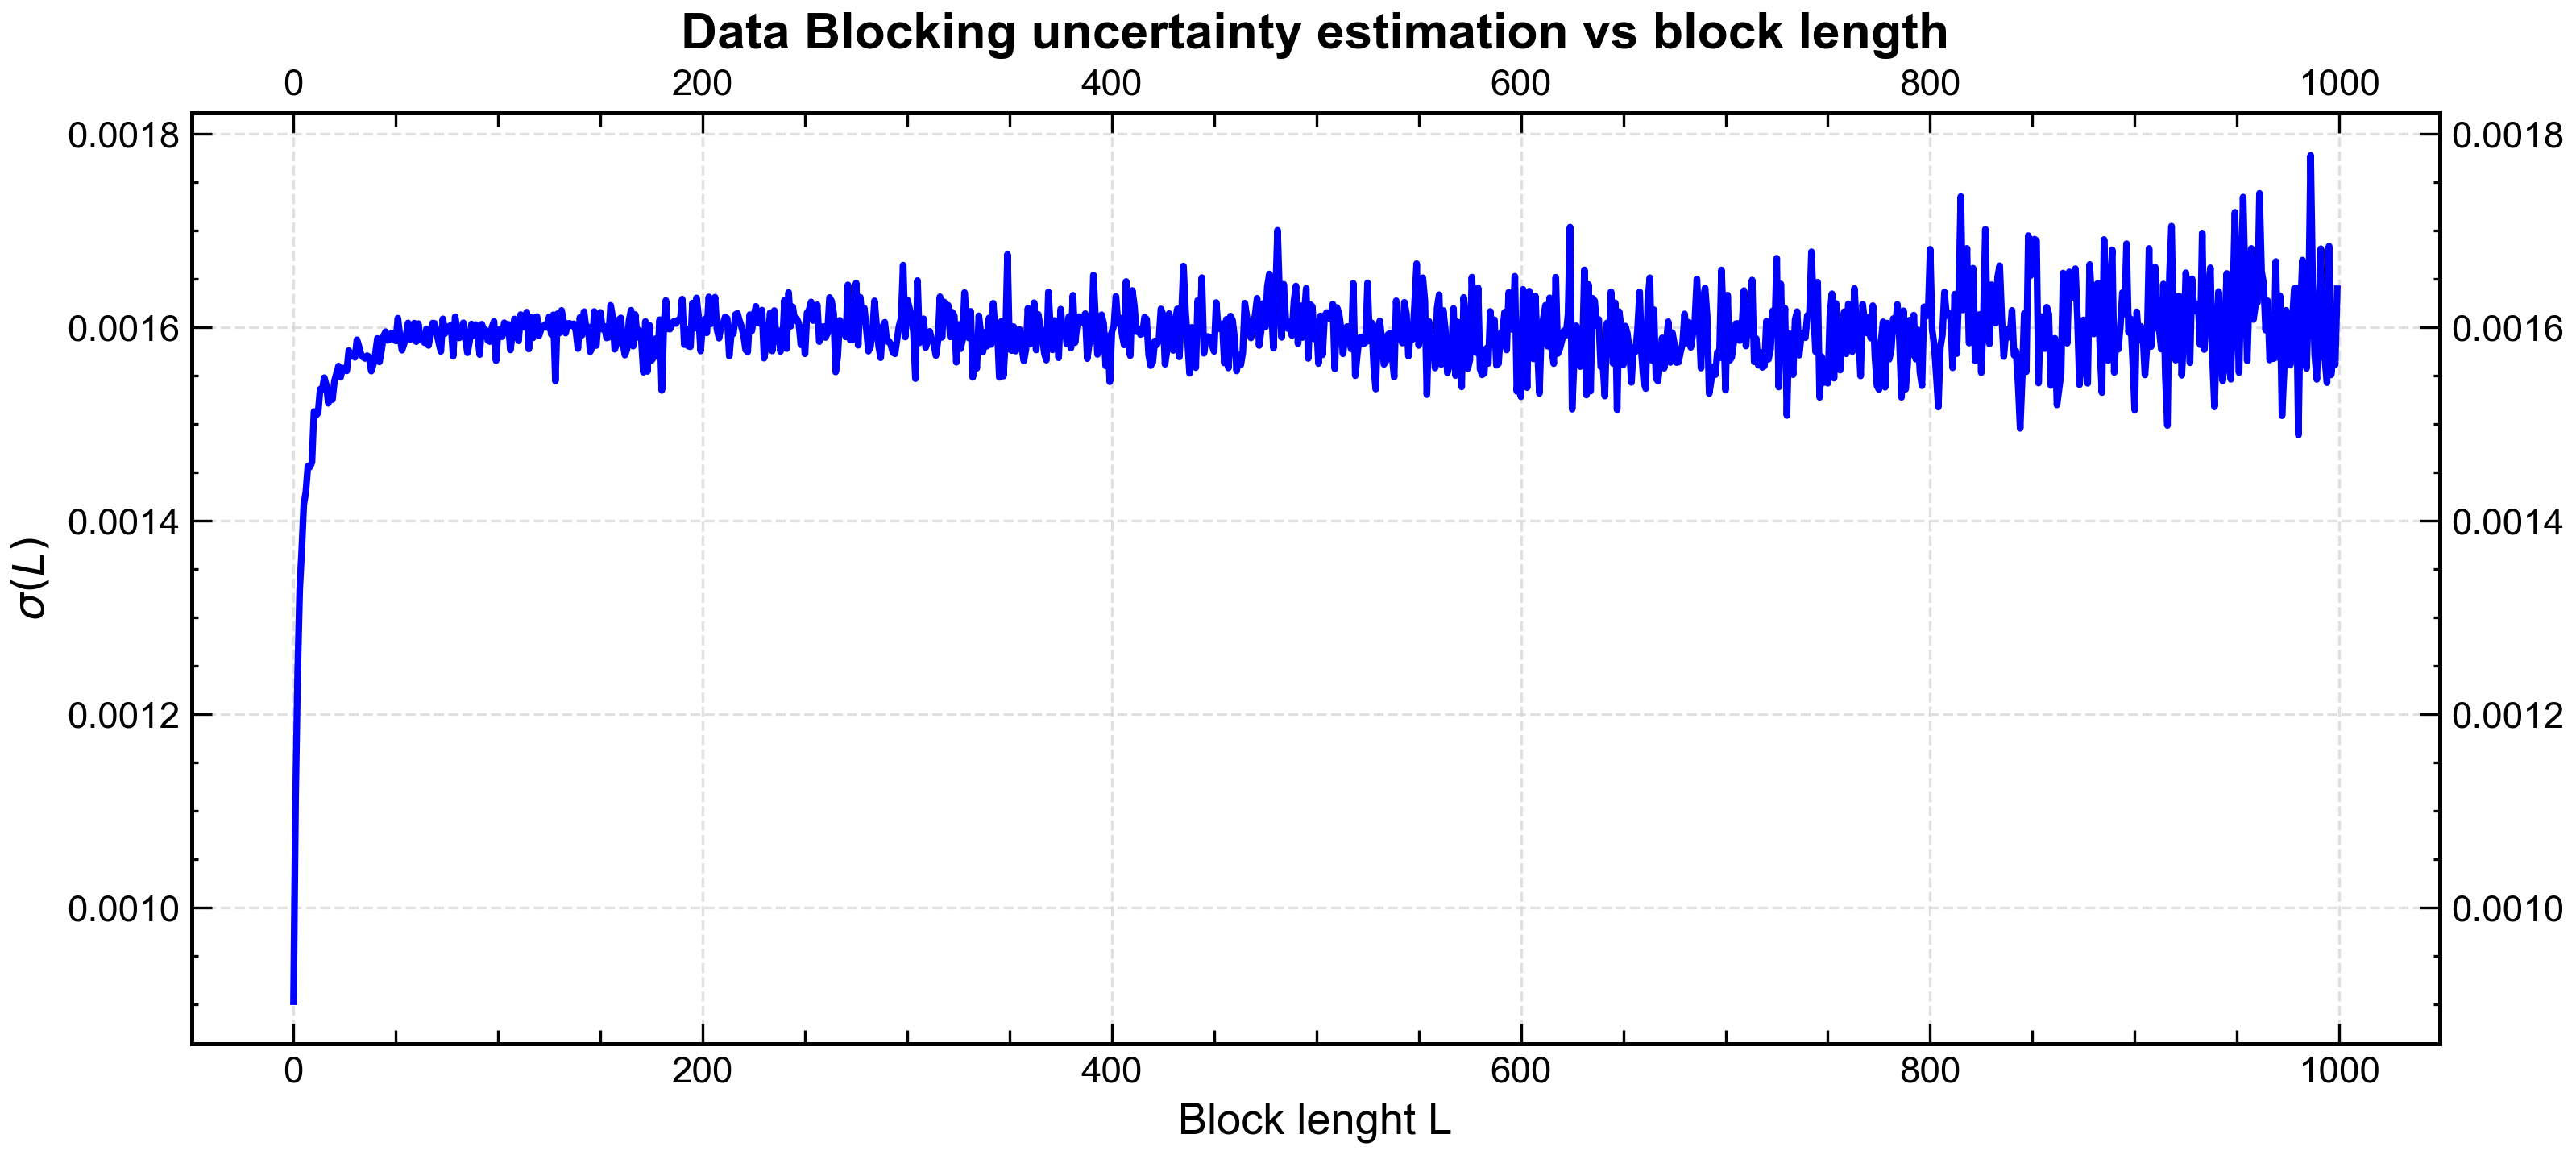

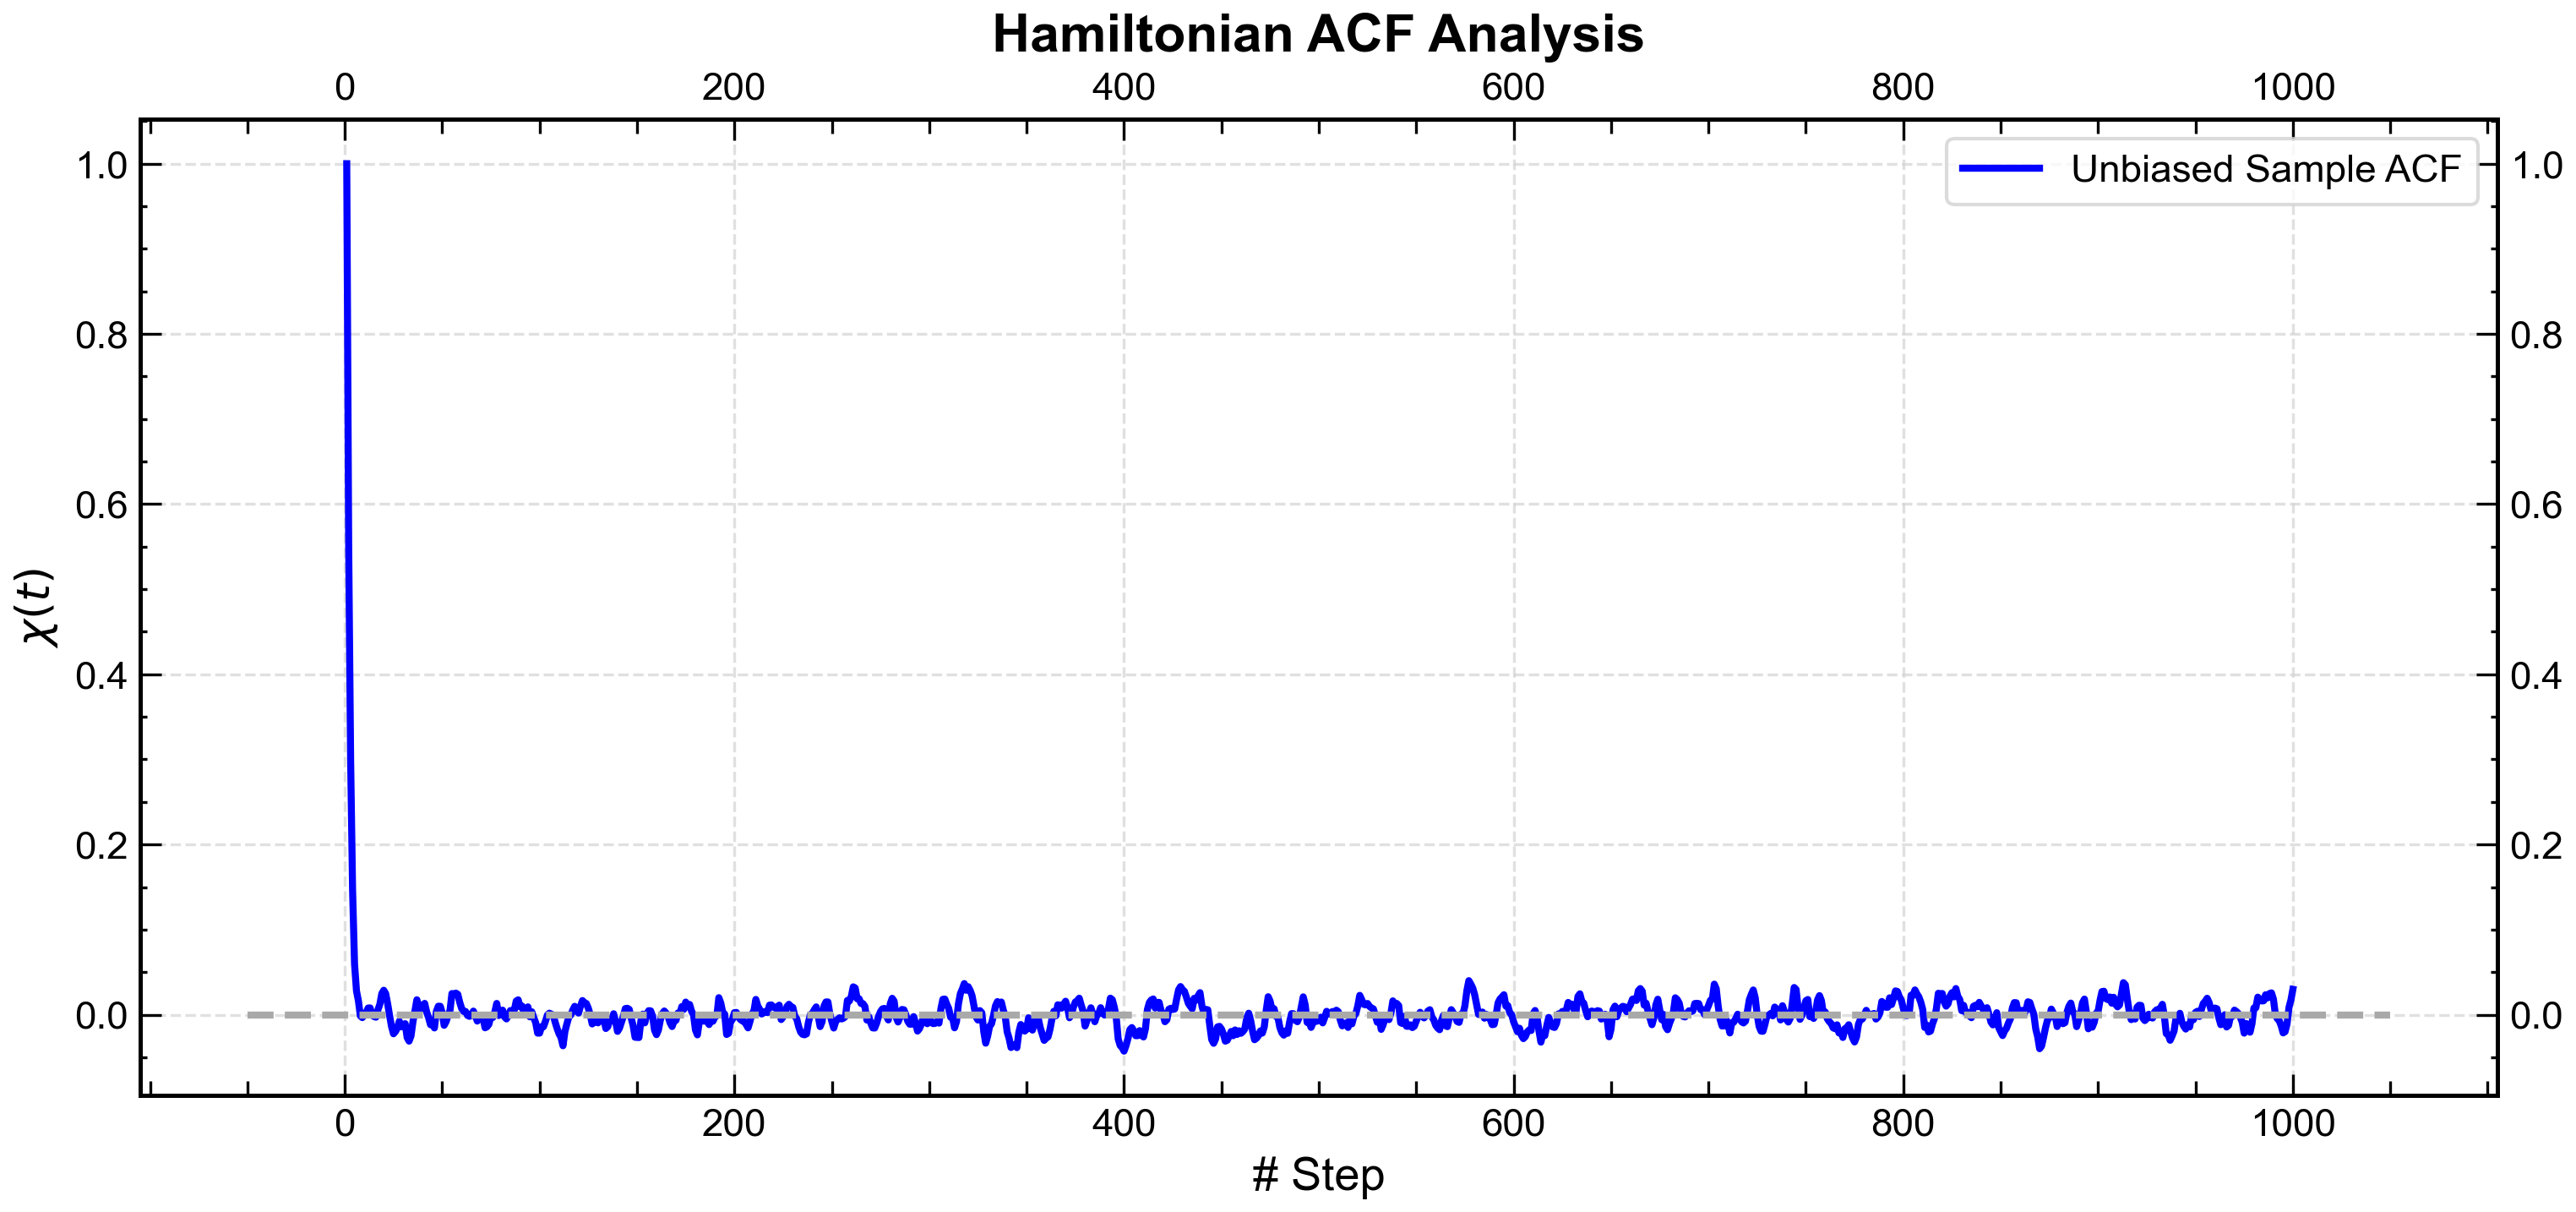

In [ ]:
err = err[:1000]
x = np.arange(0, len(err))

fig = plt.figure(figsize=(12,5))

plt.title("Data Blocking uncertainty estimation vs block length")
plt.plot(x, err, color="blue")
plt.xlabel("Block lenght L")
# plt.xlim(-10,200)
# plt.xlim(-10,1000)
plt.ylabel(r"$\sigma (L)$")

fig = plt.figure(figsize=(12, 5)) 

plt.title("Hamiltonian ACF Analysis")
plt.plot(step[:1000], acf[:1000], color="blue", label="Unbiased Sample ACF")
plt.xlabel("# Step")
plt.ylabel(r"$\chi(t)$")
plt.hlines(0, -50, 1050, color="darkgrey", linestyle="--")
plt.legend()

ct = functions.integrated_ac_time(acf)

print(f"NVE Correlation time from unbiased sample ACF : τ ≈ {ct:.2f} steps")

plt.show()

<h4>Conclusions</h4>

By examining the autocorrelation function (ACF) associated with the local energy, calculated at every Metropolis step, we observe that successive configurations sampled by the algorithm rapidly decorrelate from one another. The ACF drops effectively to zero after only three Metropolis moves, after which it exhibits only random noise caused by the stochastic fluctuations of the energy value.

Associated with the ACF study, we performed an analysis of the estimated error associated with the mean local energy, plotted as a function of the block size used in the block averaging method.

We observe that for block sizes smaller than approximately $50$ steps, the uncertainty estimate underestimates the true value. This systematic underestimation occurs because the sampled energy values at different timesteps are still statistically correlated, violating the assumption of independent and identically distributed (i.i.d.) data required for accurate error propagation.

As the block size increases to approximately $200–400$ steps, the estimated error saturates at a constant value. This saturation point indicates that the block size has become significantly larger than the correlation time of the sampling process, confirming that the average energy within each block can now be treated as an independent statistical variable. To ensure the statistical validity of the uncertainty associated with the mean local energy, we chose a final block size of $1000$ steps.

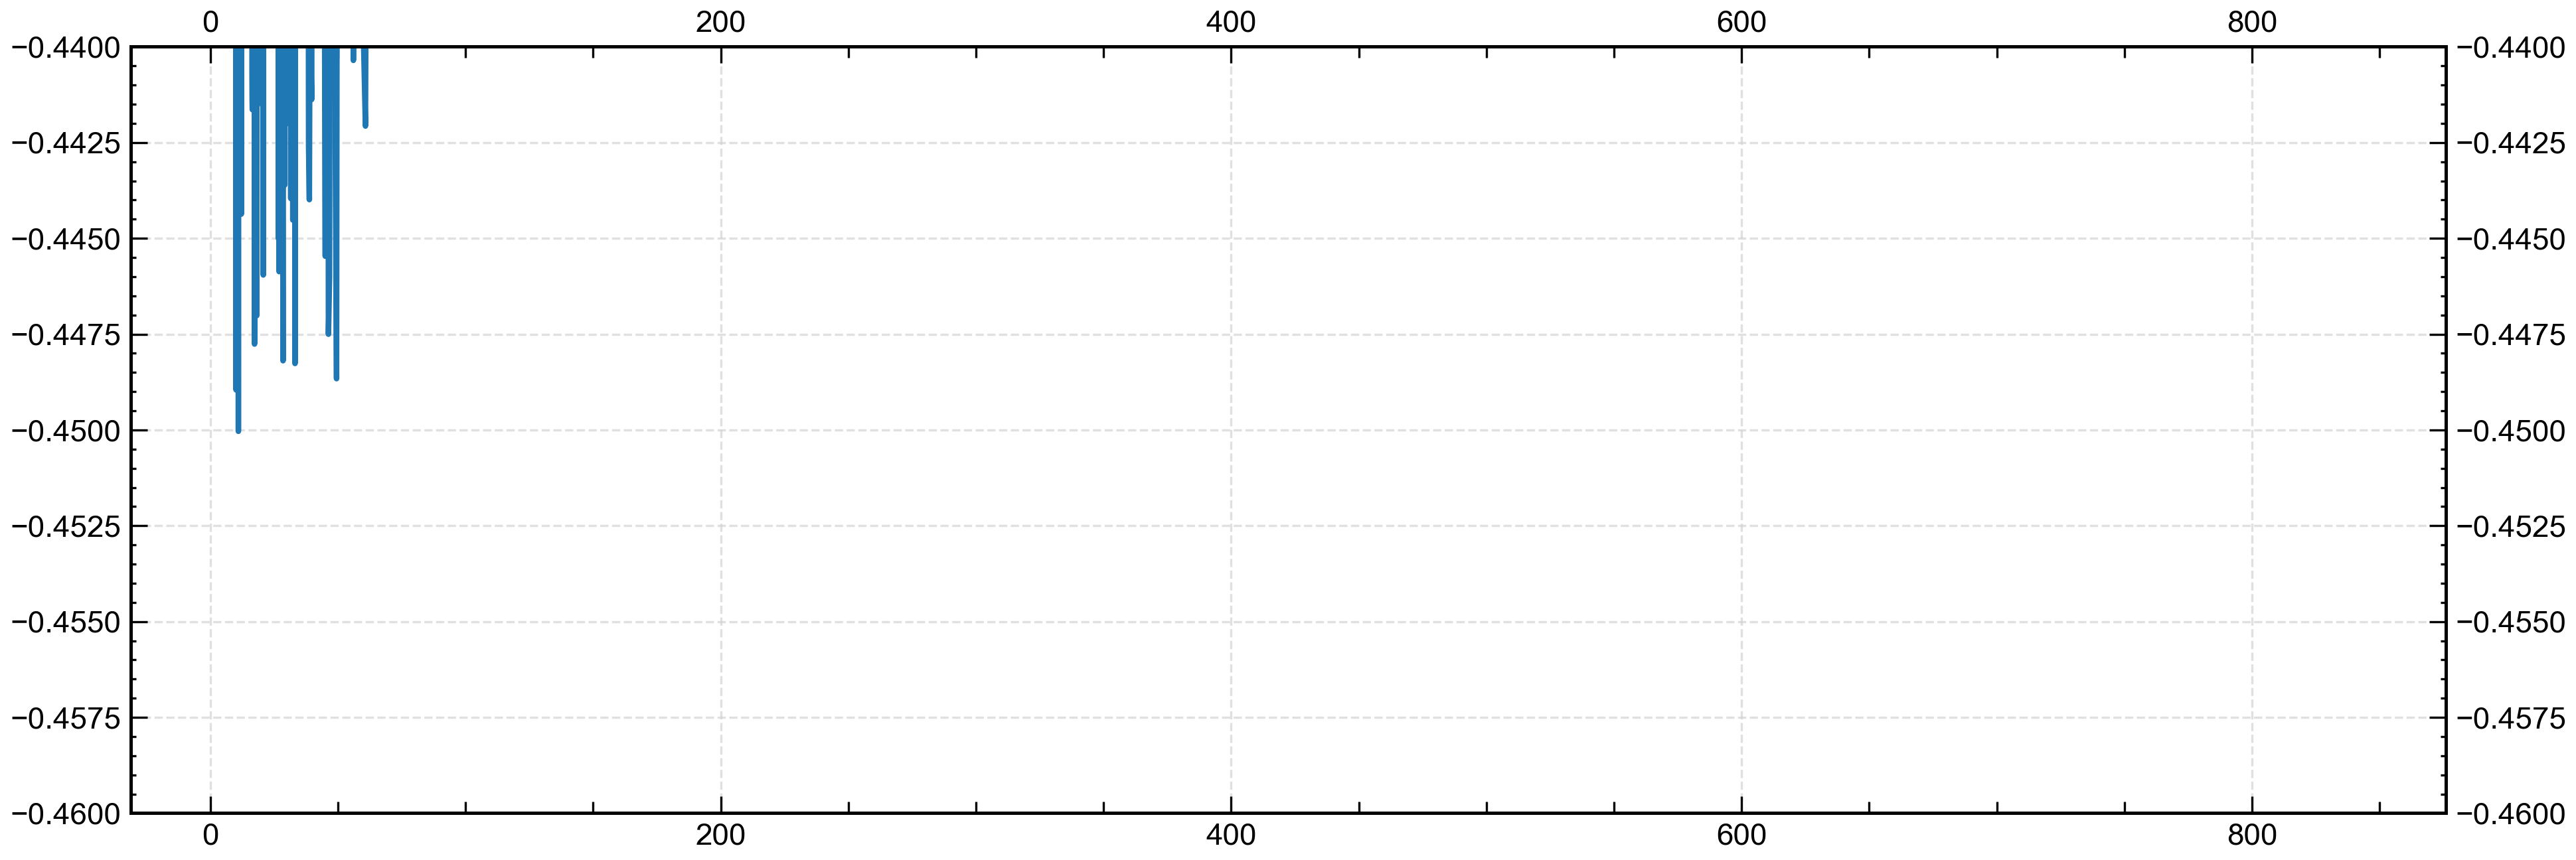

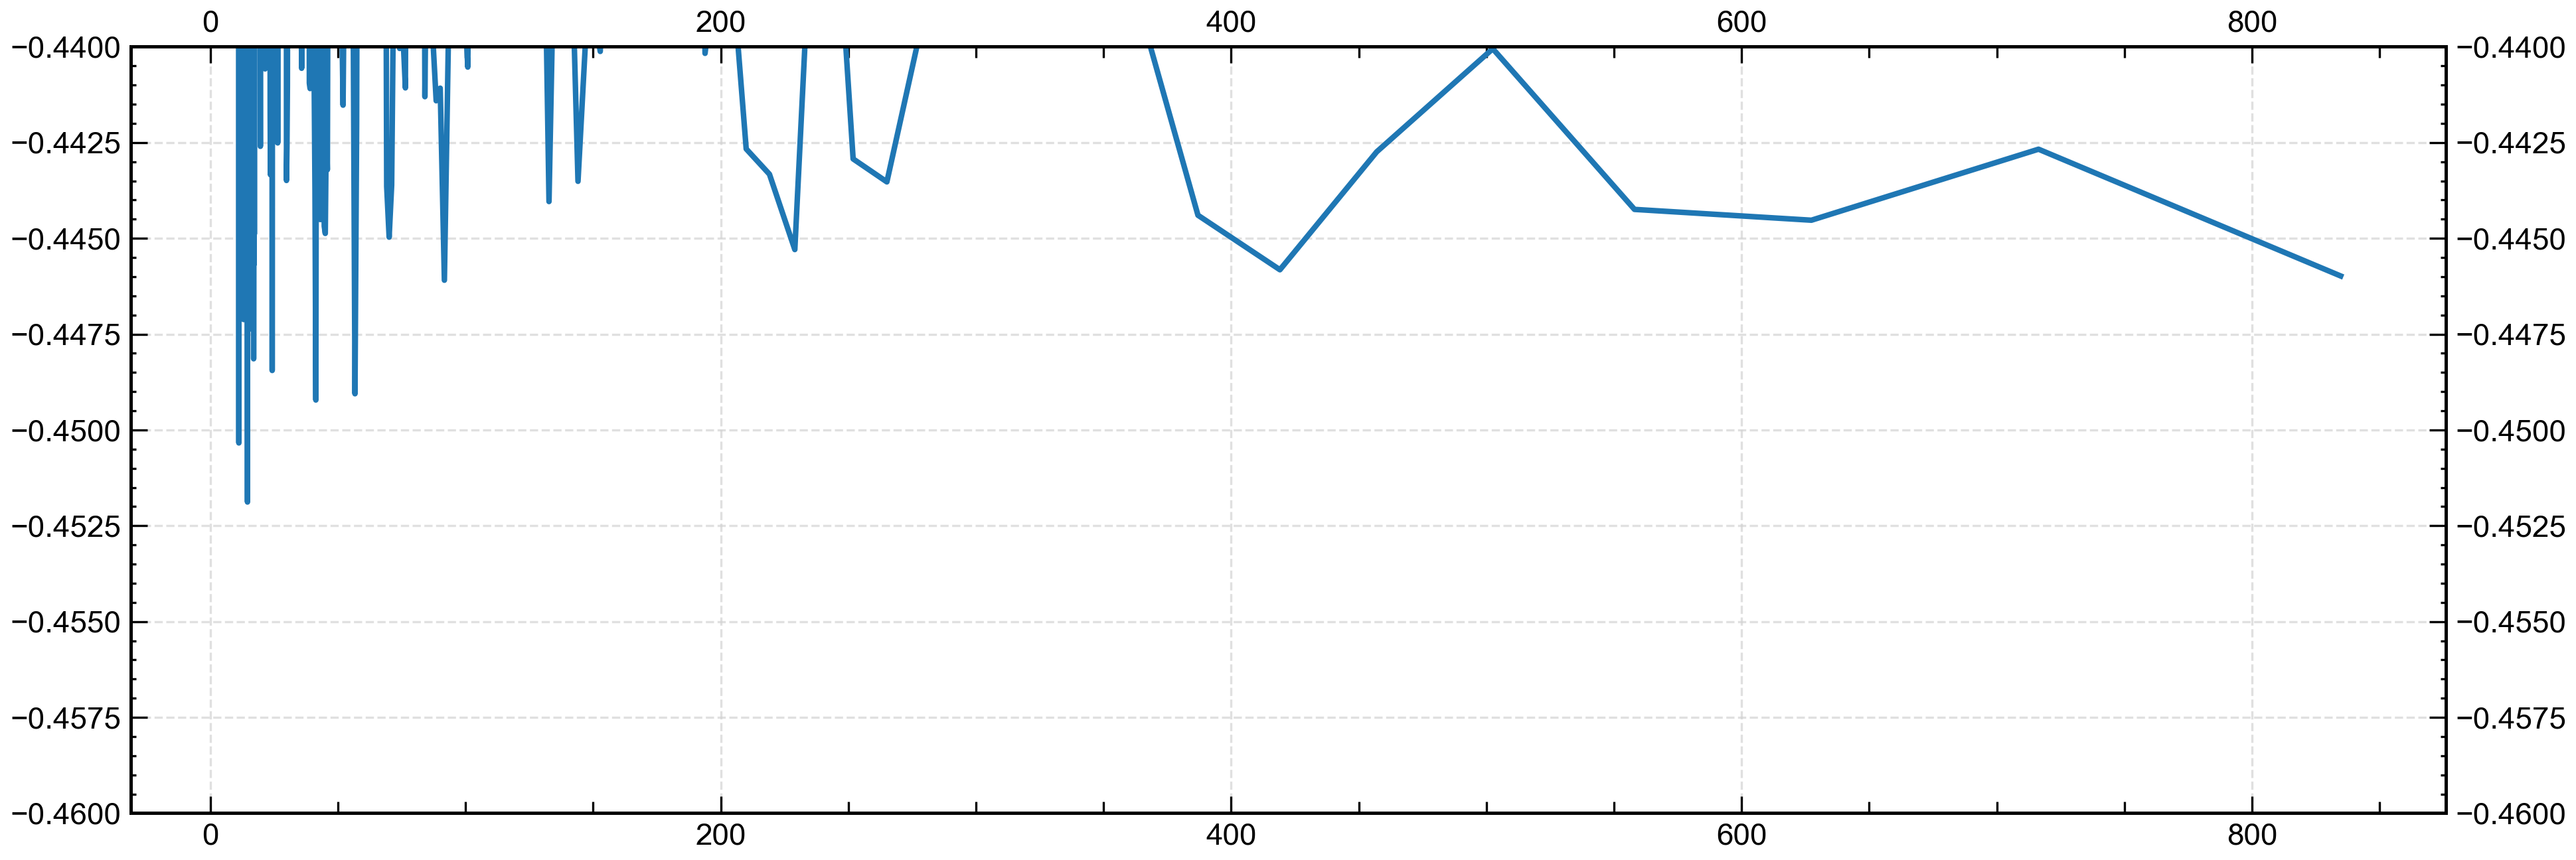

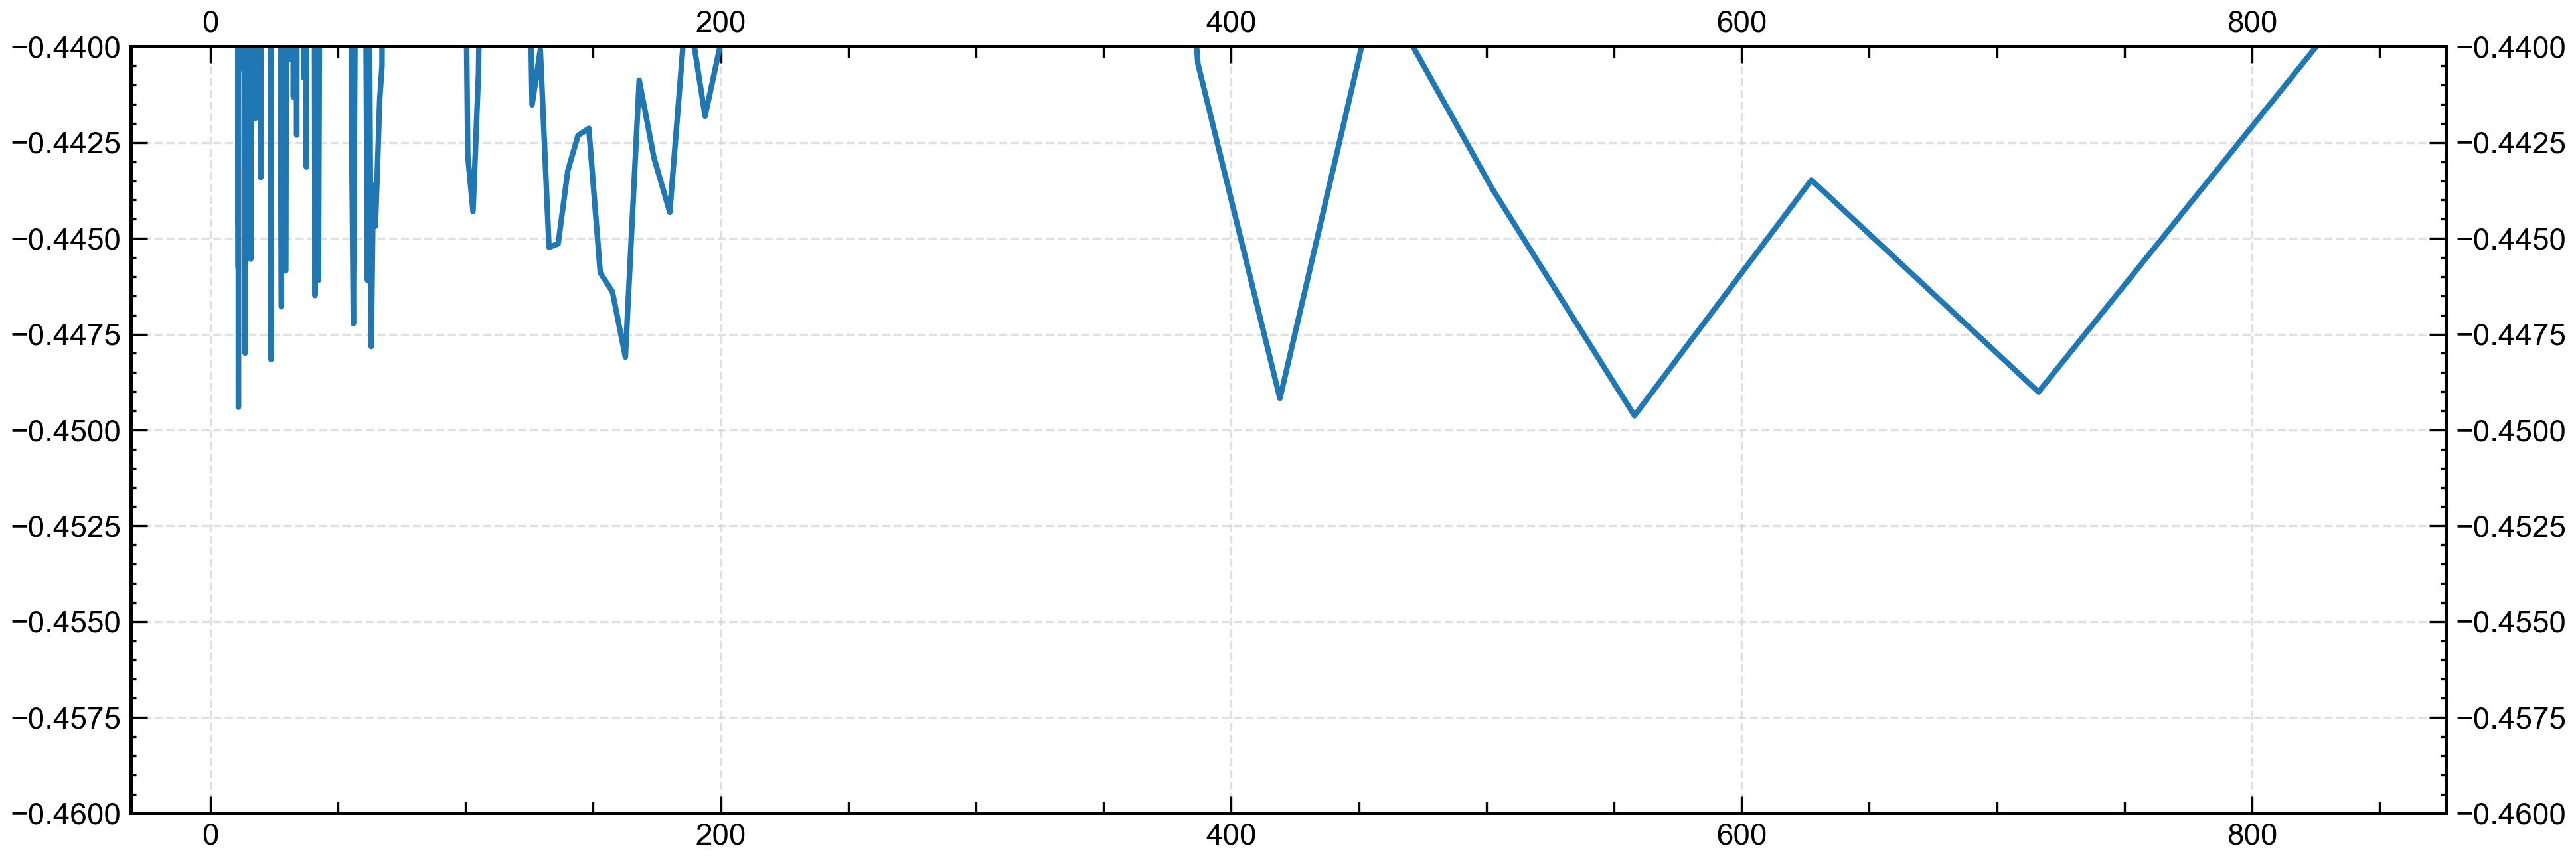

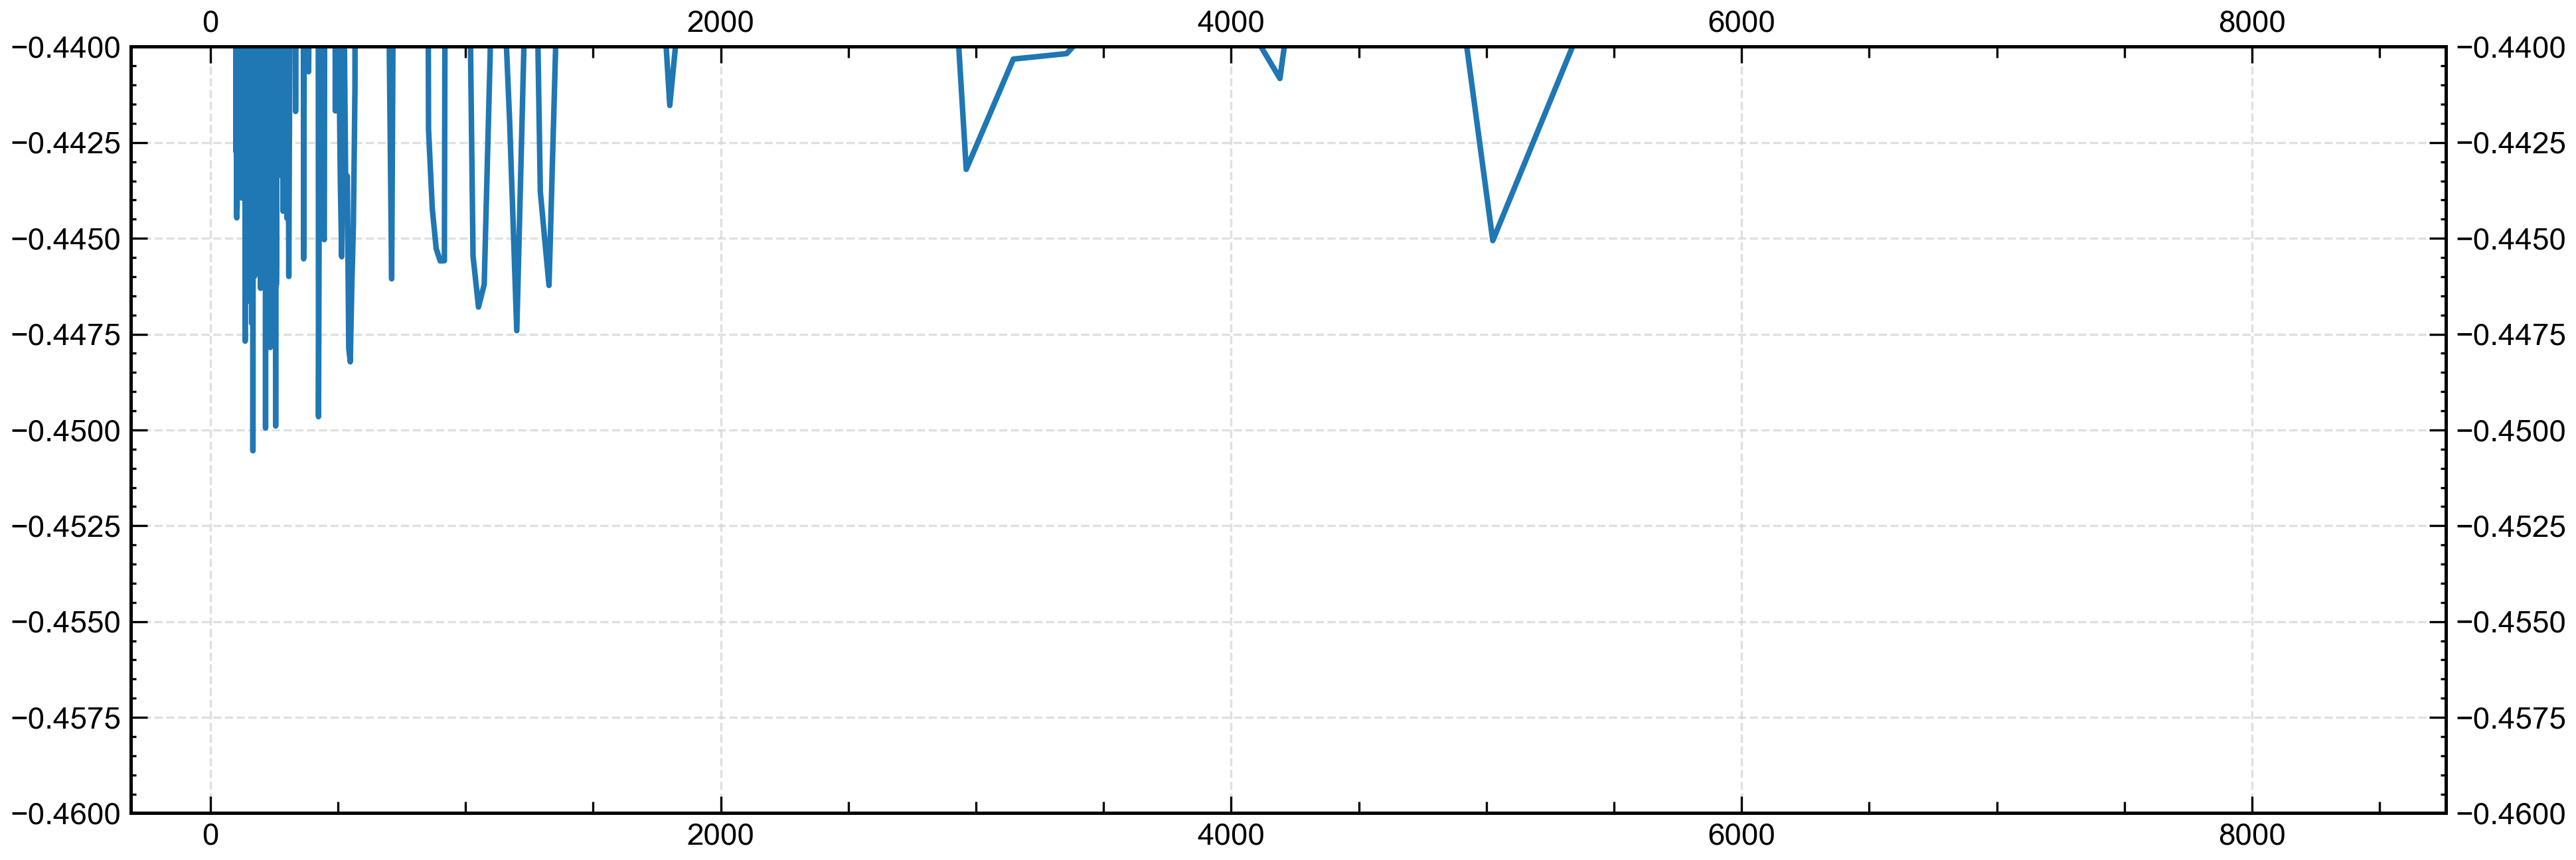

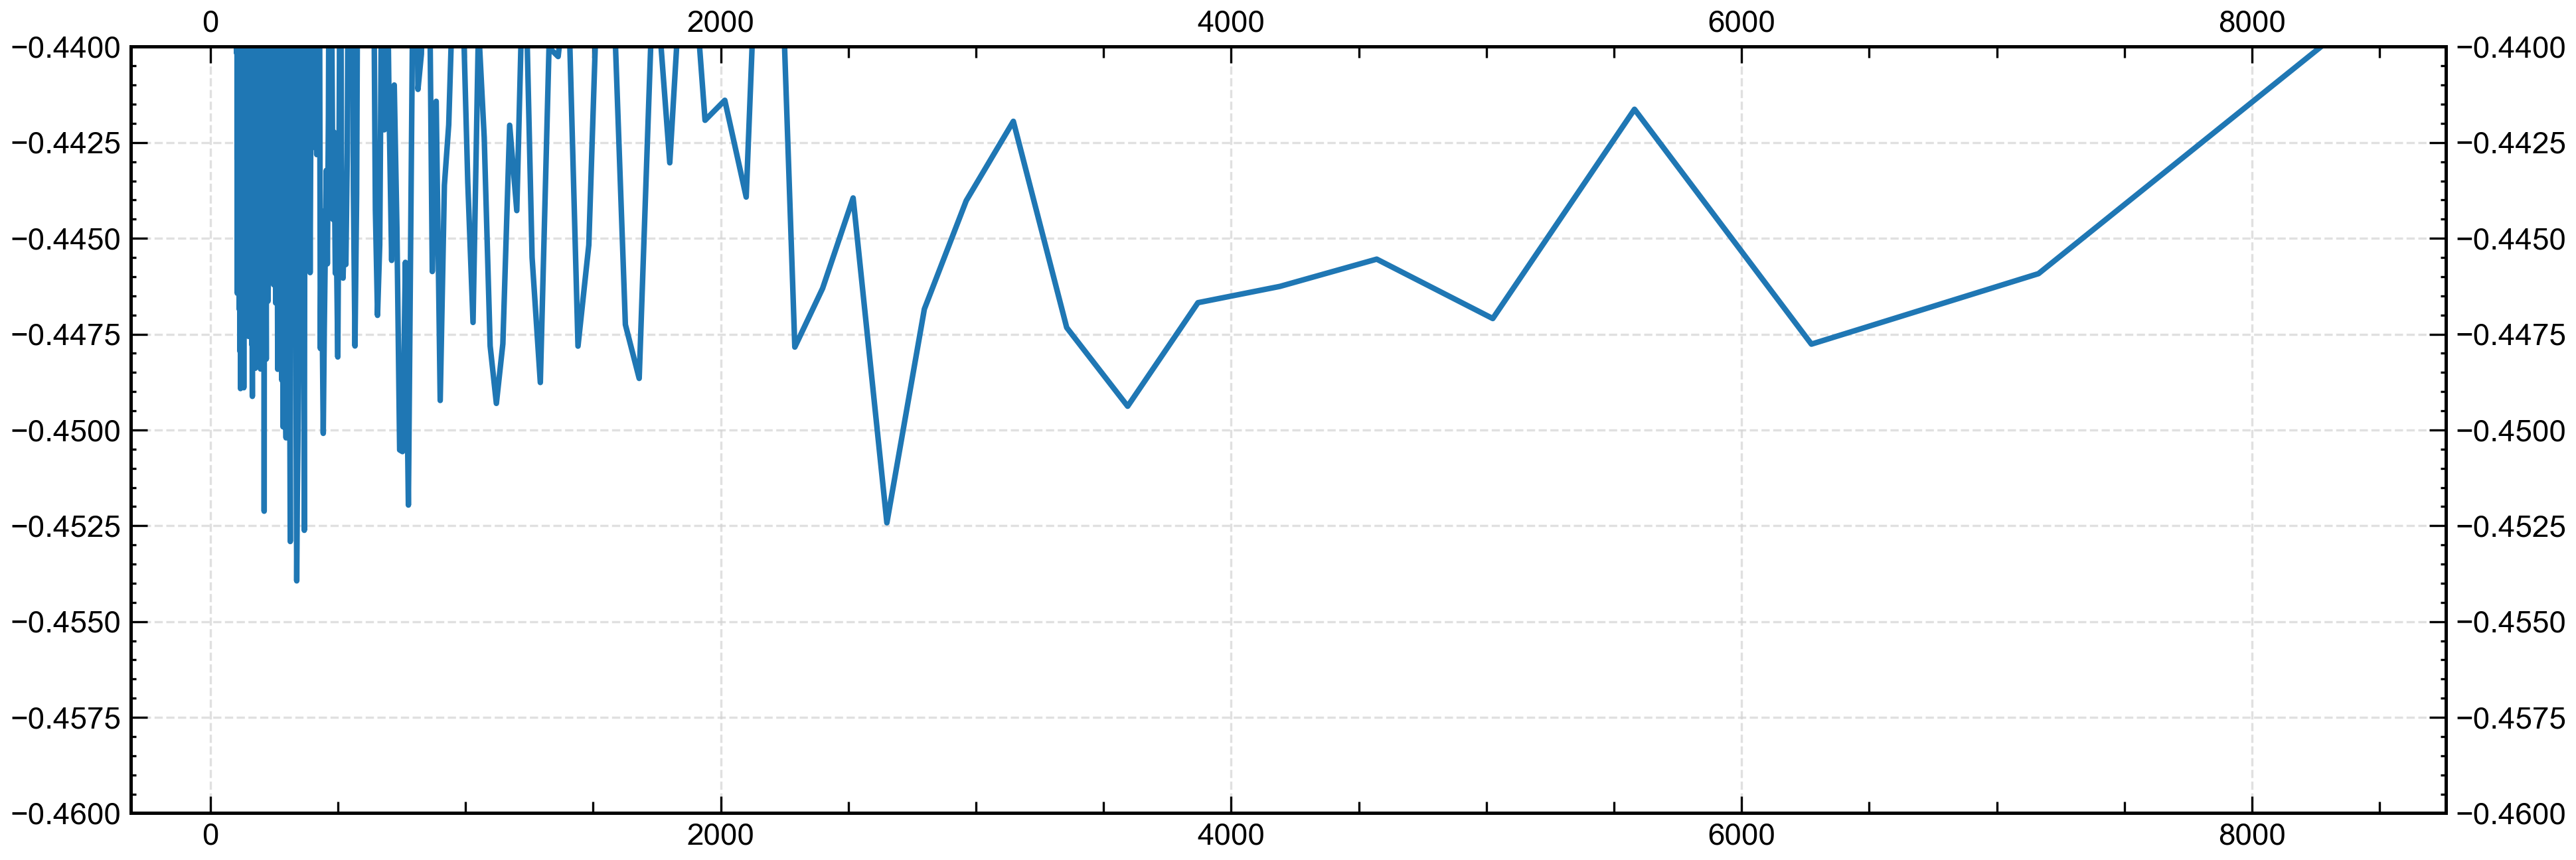

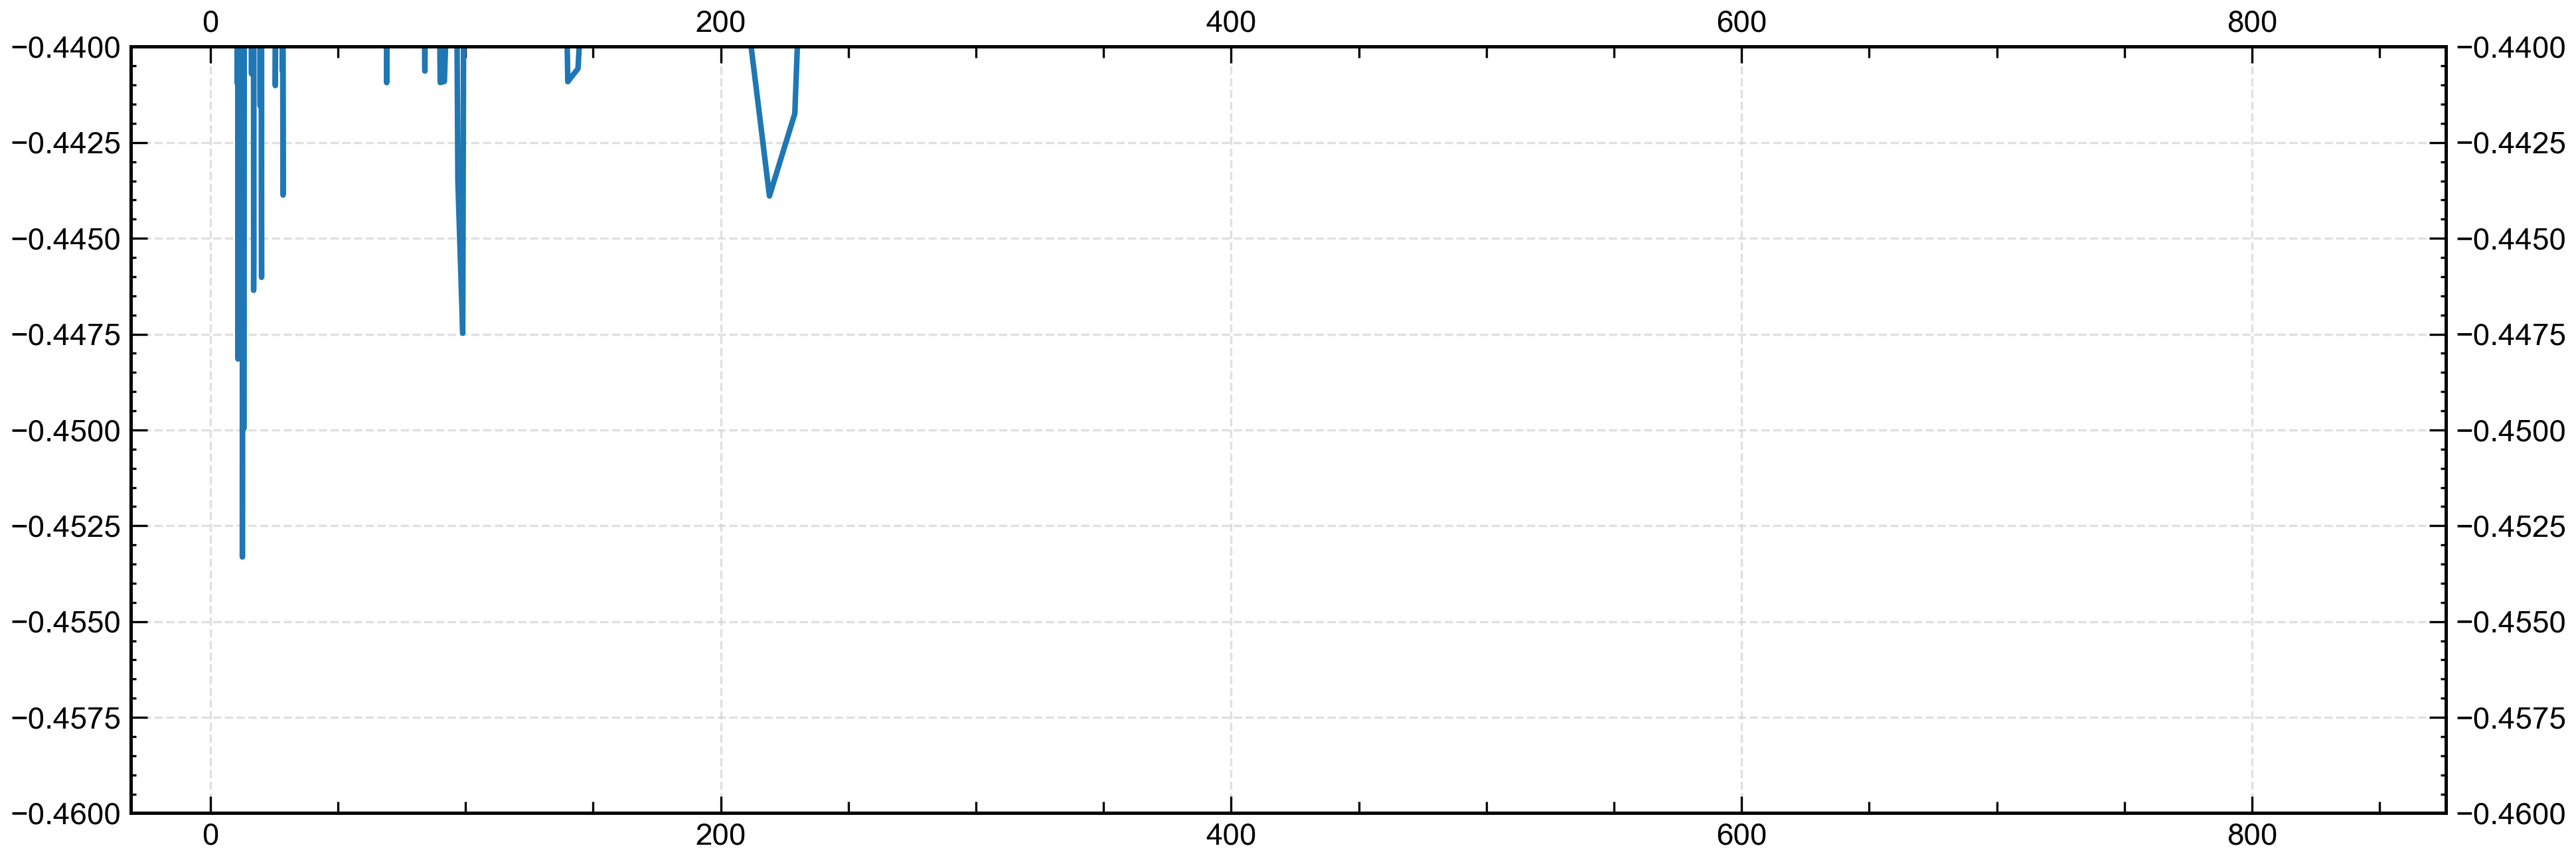

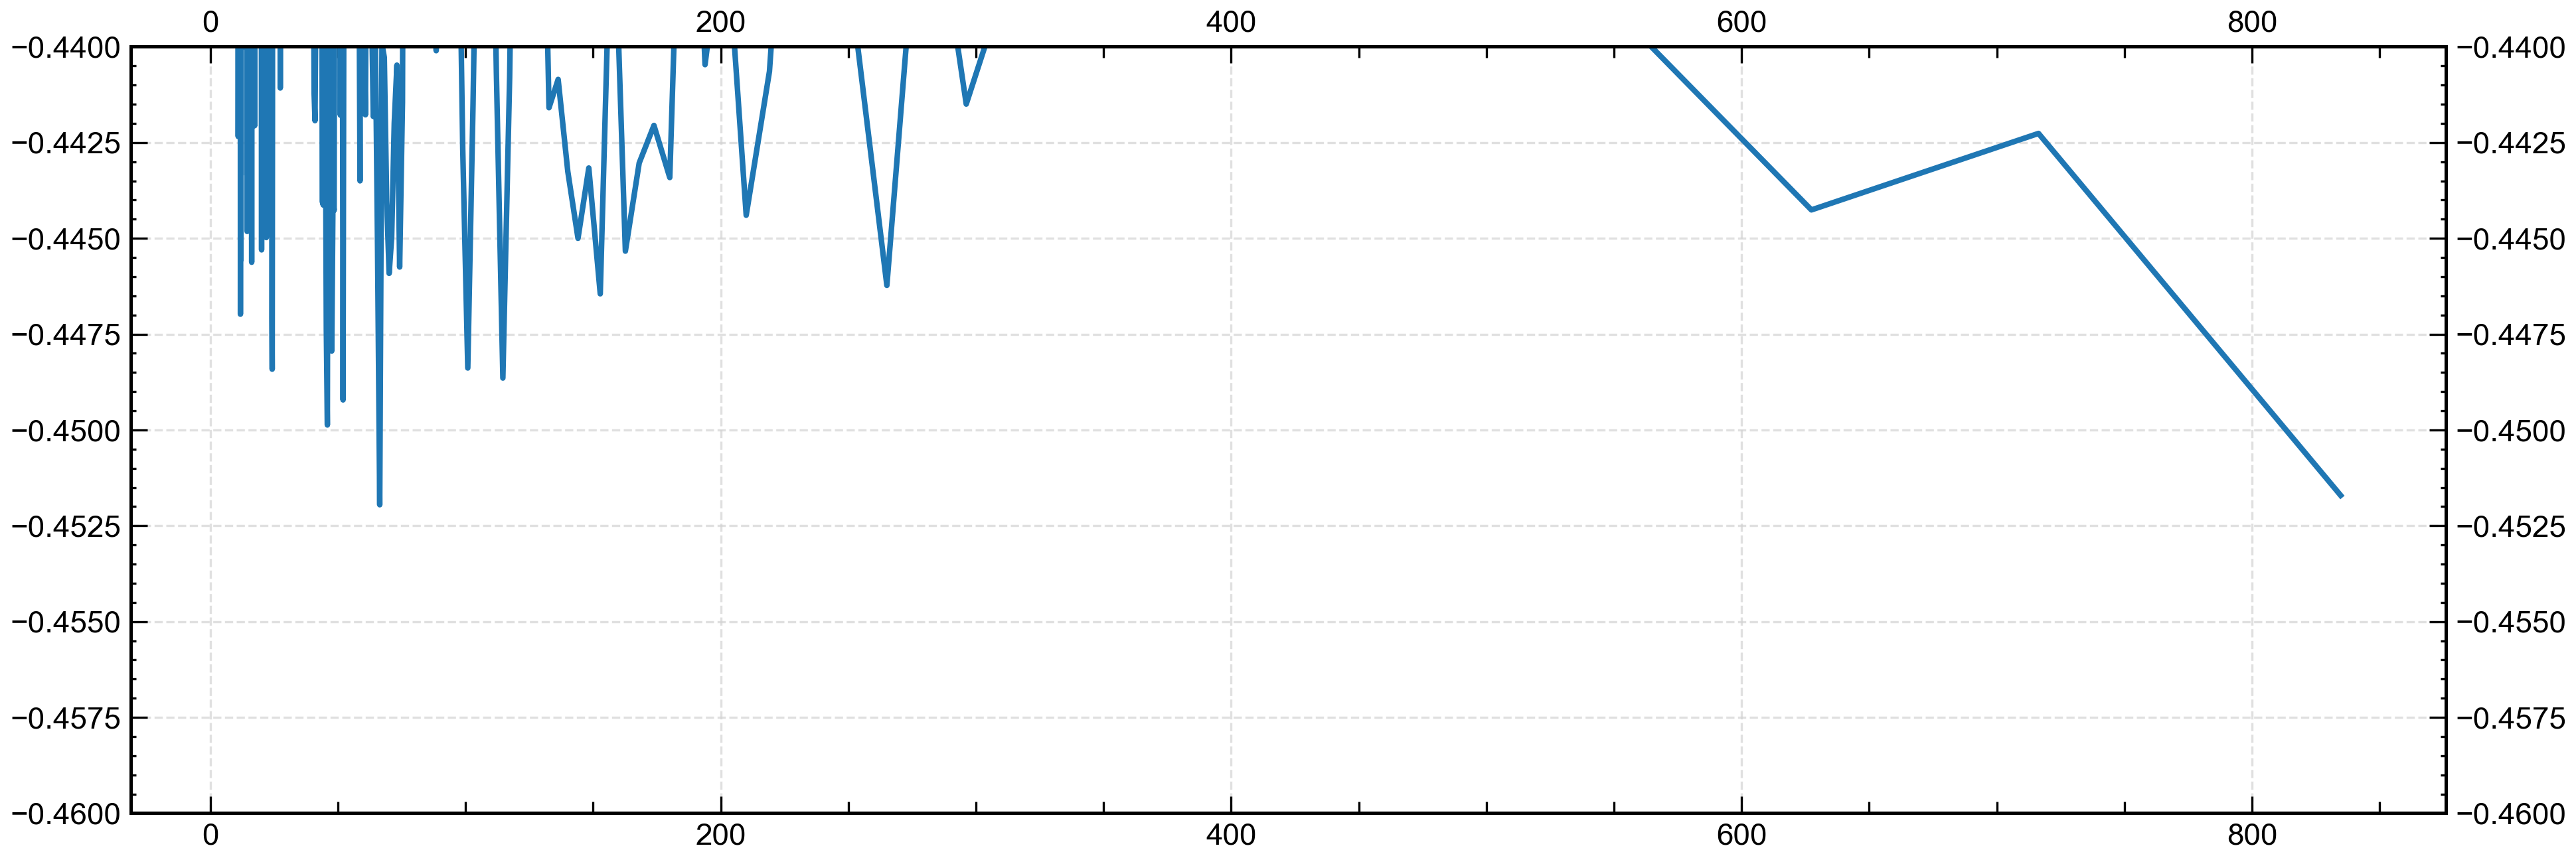

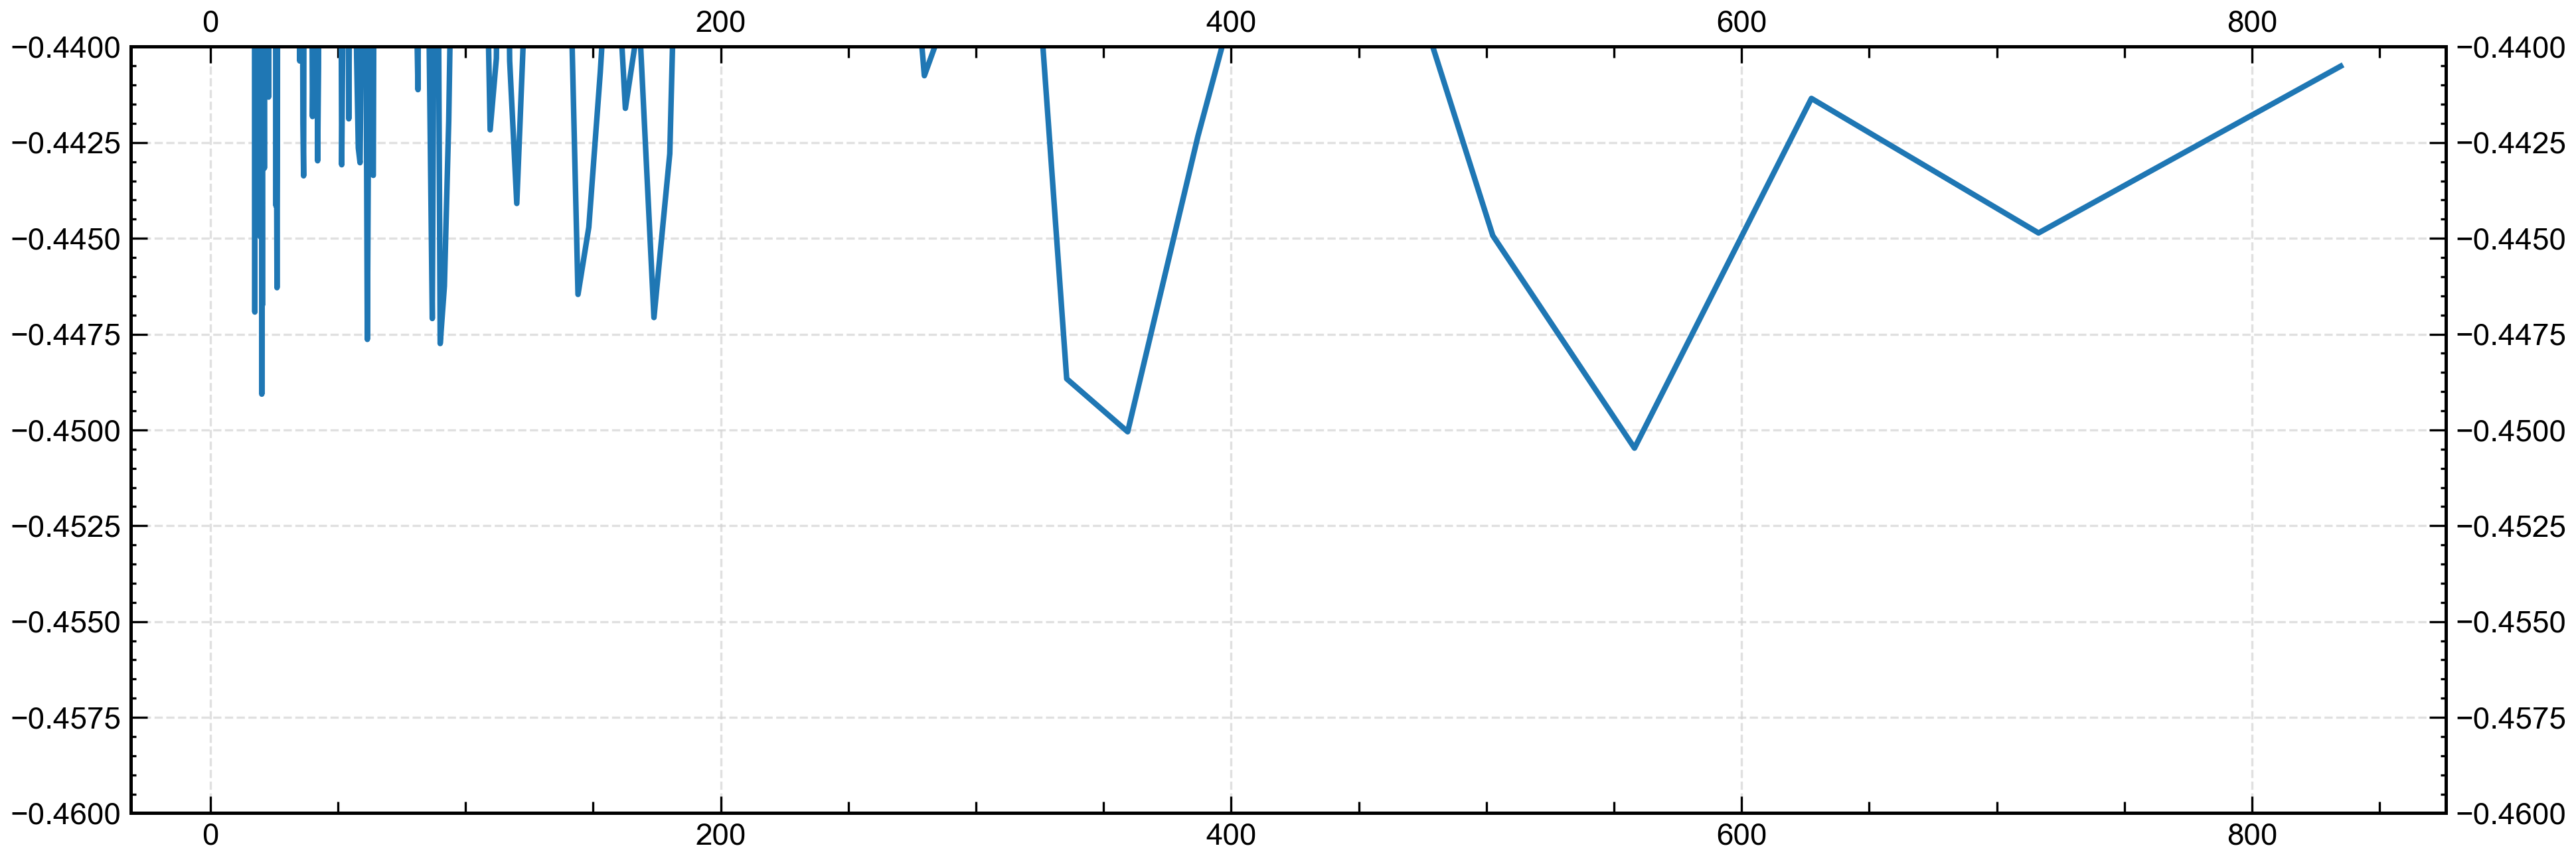

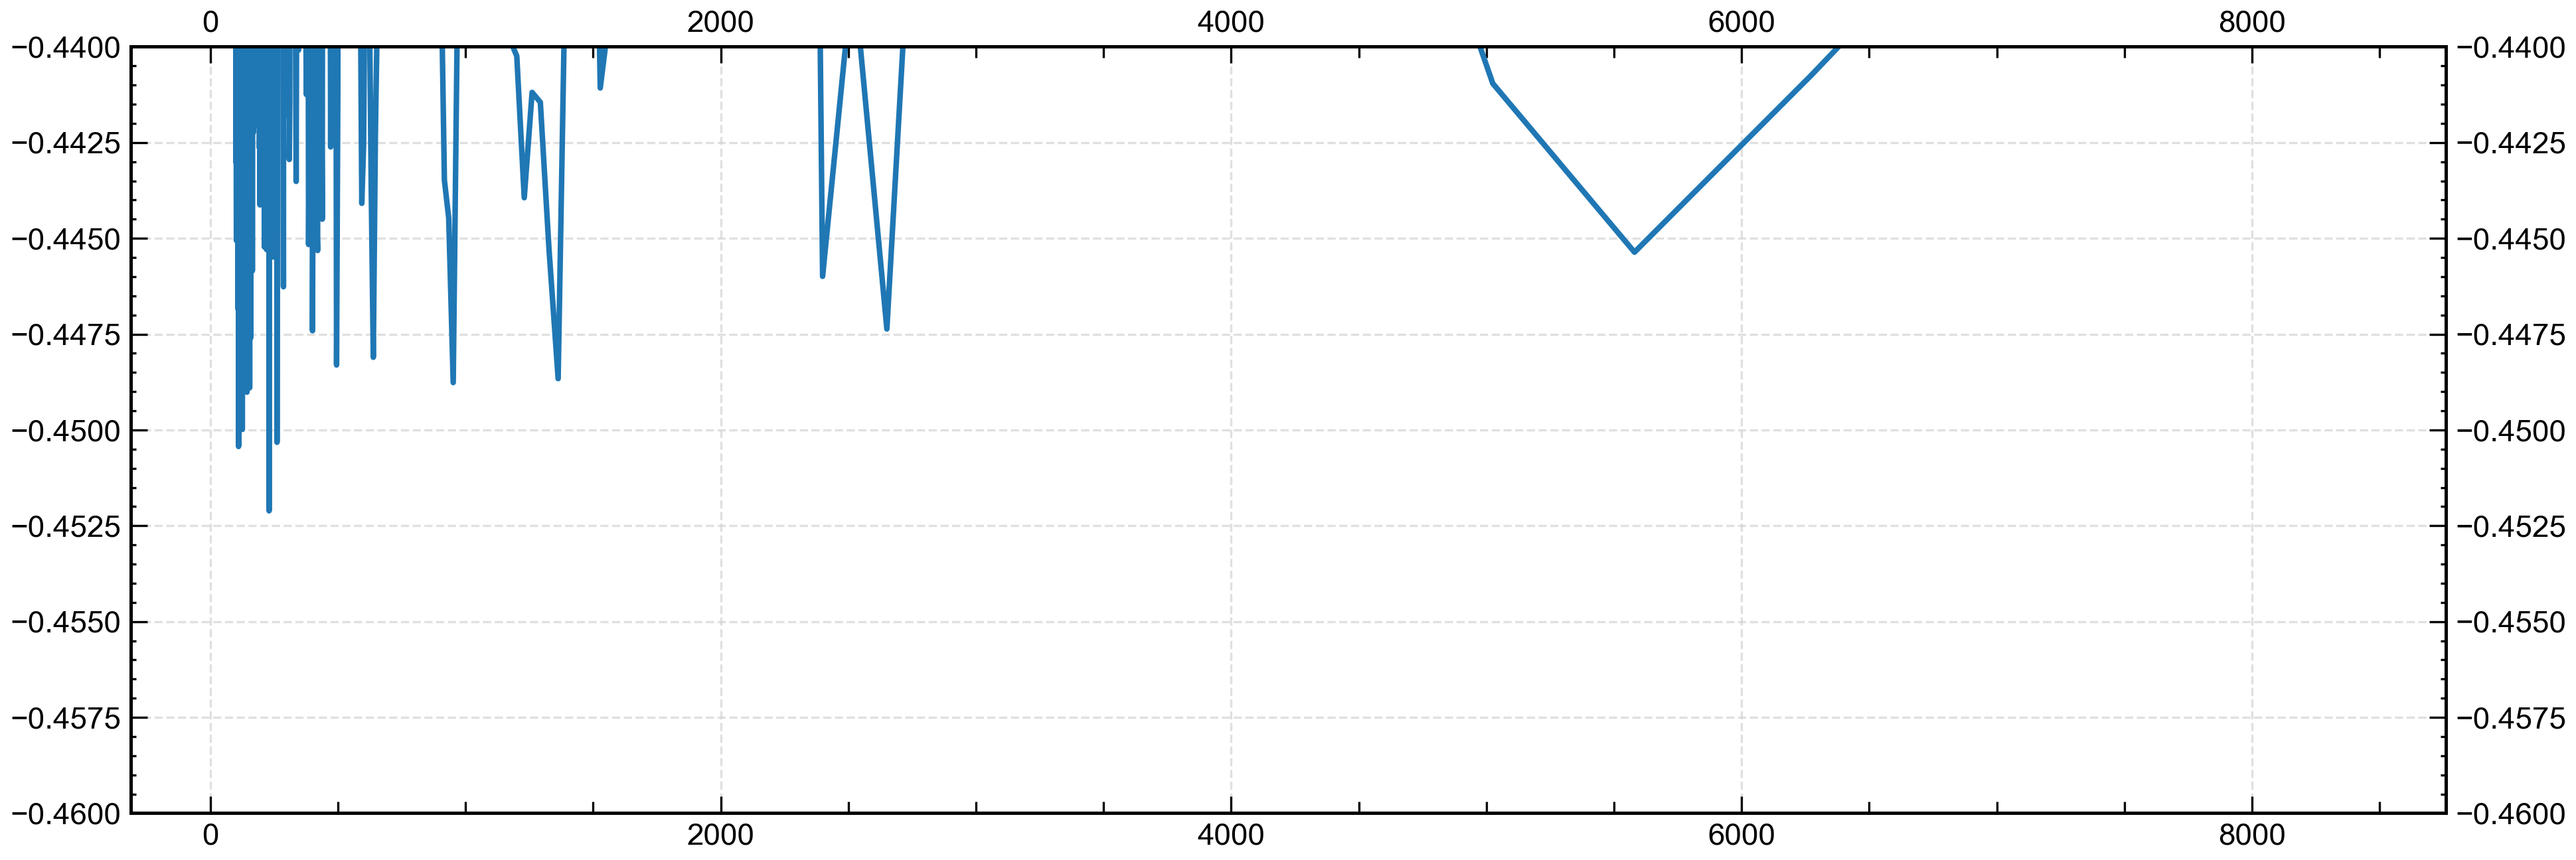

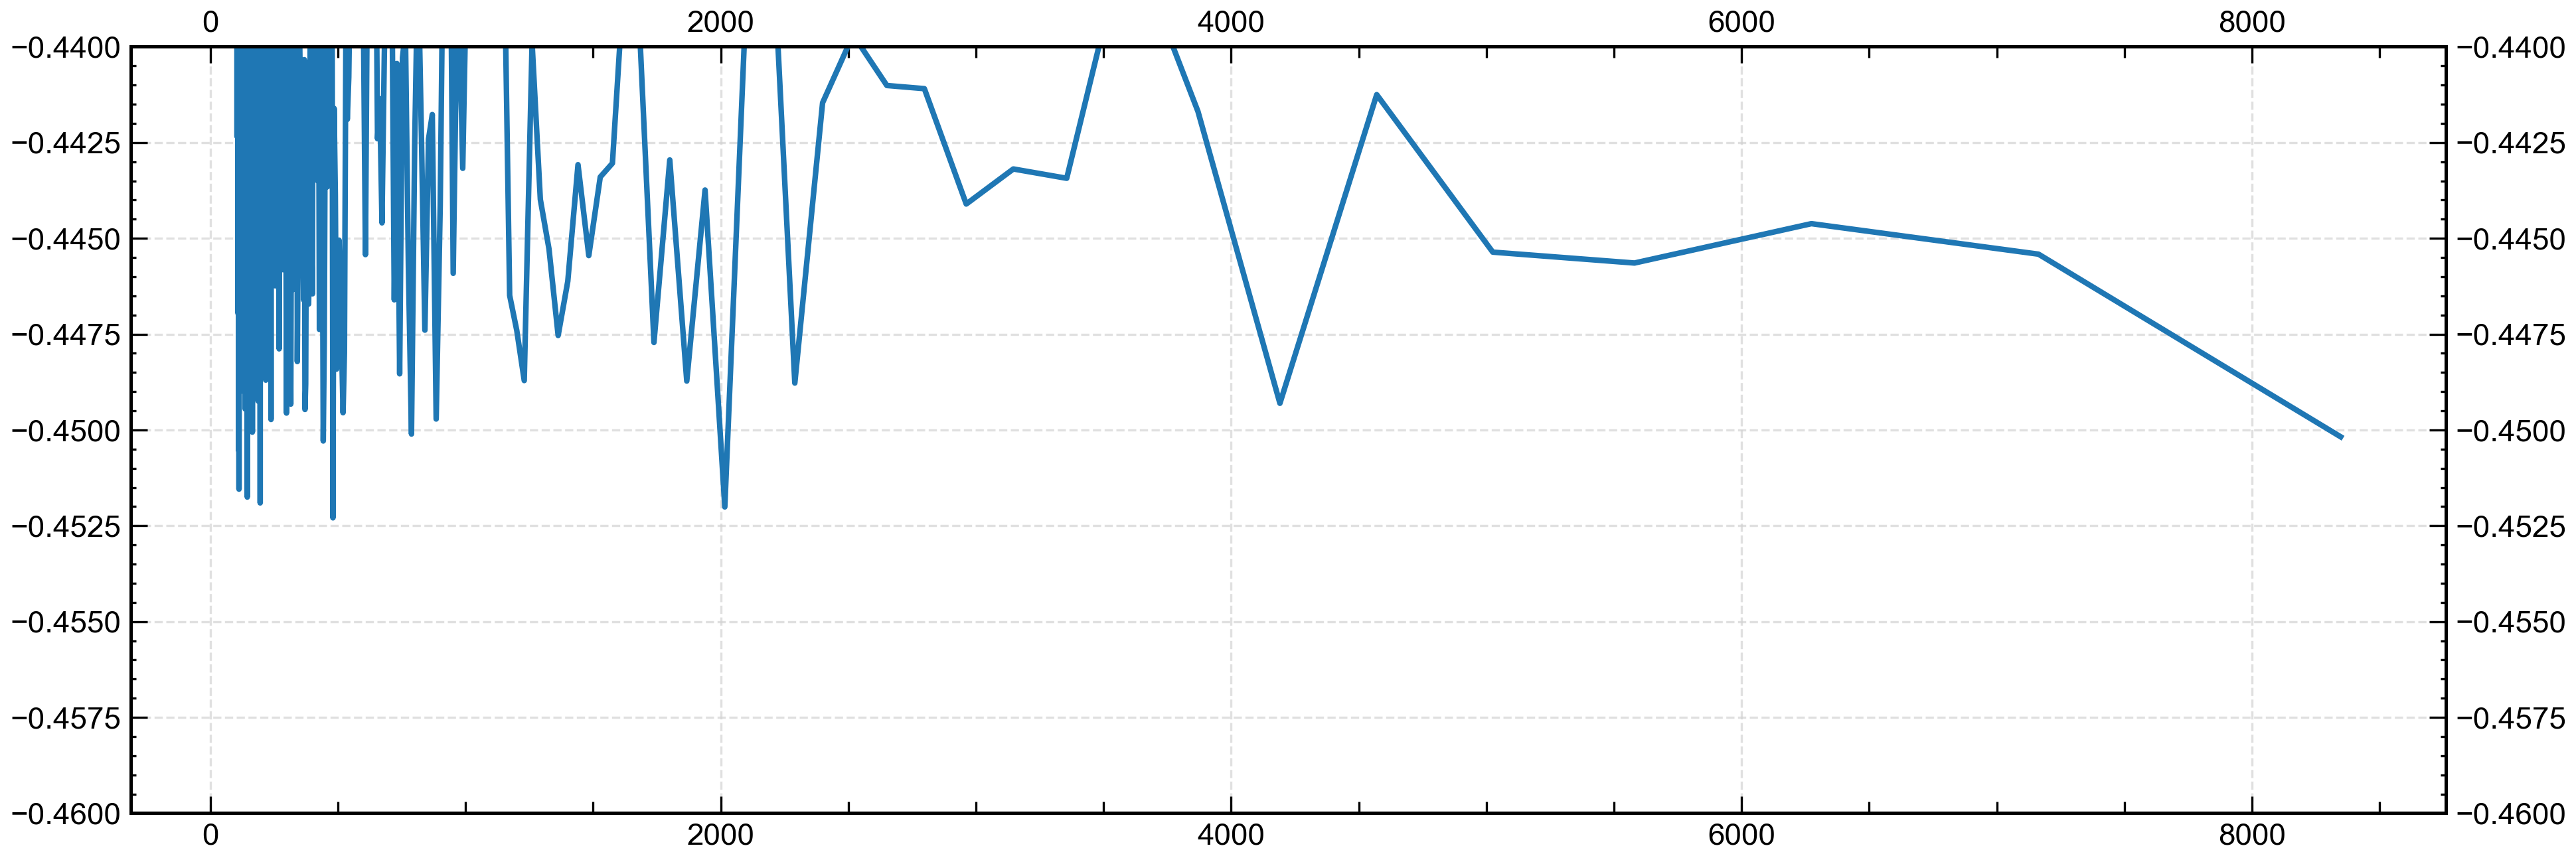

In [42]:
t1, H1 = np.loadtxt("runs/run_01/OUTPUT/data.dat", usecols=(0,3), unpack=True)
t2, H2 = np.loadtxt("runs/run_02/OUTPUT/data.dat", usecols=(0,3), unpack=True)
t3, H3 = np.loadtxt("runs/run_03/OUTPUT/data.dat", usecols=(0,3), unpack=True)
t4, H4 = np.loadtxt("runs/run_04/OUTPUT/data.dat", usecols=(0,3), unpack=True)
t5, H5 = np.loadtxt("runs/run_05/OUTPUT/data.dat", usecols=(0,3), unpack=True)
t6, H6 = np.loadtxt("runs/run_06/OUTPUT/data.dat", usecols=(0,3), unpack=True)
t7, H7 = np.loadtxt("runs/run_07/OUTPUT/data.dat", usecols=(0,3), unpack=True)
t8, H8 = np.loadtxt("runs/run_08/OUTPUT/data.dat", usecols=(0,3), unpack=True)
t9, H9 = np.loadtxt("runs/run_09/OUTPUT/data.dat", usecols=(0,3), unpack=True)
t10, H10 = np.loadtxt("runs/run_10/OUTPUT/data.dat", usecols=(0,3), unpack=True)
beta1 = 1/t1
beta2 = 1/t2
beta3 = 1/t3
beta4 = 1/t4
beta5 = 1/t5
beta6 = 1/t6
beta7 = 1/t7
beta8 = 1/t8
beta9 = 1/t9
beta10 = 1/t10

fig = plt.figure(figsize=(15,5))
plt.plot(beta1, H1)
# #plt.xlim(8, 15)
plt.ylim(-0.46, -0.44)

fig = plt.figure(figsize=(15,5))
plt.plot(beta2, H2)
# #plt.xlim(8, 15)
plt.ylim(-0.46, -0.44)

fig = plt.figure(figsize=(15,5))
plt.plot(beta3, H3)
# #plt.xlim(8, 15)
plt.ylim(-0.46, -0.44)

fig = plt.figure(figsize=(15,5))
plt.plot(beta4, H4)
# #plt.xlim(8, 15)
plt.ylim(-0.46, -0.44)

fig = plt.figure(figsize=(15,5))
plt.plot(beta5, H5)
# #plt.xlim(8, 15)
plt.ylim(-0.46, -0.44)

fig = plt.figure(figsize=(15,5))
plt.plot(beta6, H6)
# #plt.xlim(8, 15)
plt.ylim(-0.46, -0.44)

fig = plt.figure(figsize=(15,5))
plt.plot(beta7, H7)
# plt.xlim(8, 15)
plt.ylim(-0.46, -0.44)

fig = plt.figure(figsize=(15,5))
plt.plot(beta8, H8)
# plt.xlim(8, 15)
plt.ylim(-0.46, -0.44)

fig = plt.figure(figsize=(15,5))
plt.plot(beta9, H9)
# plt.xlim(8, 15)
plt.ylim(-0.46, -0.44)

fig = plt.figure(figsize=(15,5))
plt.plot(beta10, H10)
# plt.xlim(8, 15)
plt.ylim(-0.46, -0.44)


plt.show()